# **Project Name** - Integrated Retail Analytics for Store Optimization and Demand Forecasting

##### **Project Type** - EDA / Regression / Unsupervised Learning / Anomaly Detection
##### **Contribution** - Individual
##### **Team Member 1 -** Prateek Kishor Joshi

# **Project Summary -**

Retail chains operate on thin margins where over-stocking ties up working capital and under-stocking causes lost sales and poor customer experience. This project builds an integrated retail analytics workflow using weekly data from **45 stores, 81 departments and 143 weeks (Feb-2010 to Oct-2012)**. The objective is to identify abnormal sales behaviour, segment stores into operationally useful groups, infer department associations for cross-selling, forecast short-term demand, evaluate external economic factors, and translate the results into practical inventory and marketing actions.

The source data consists of three tables: store-department weekly sales, a weekly feature table containing temperature, fuel price, five anonymised markdown series, CPI, unemployment and holiday information, and a store master containing store type and size. After merging the files, the analysis contains **421,570 sales rows**. The markdown variables are structurally missing before the promotion programme became available in November 2011, so missing markdowns are represented as zero together with an availability indicator rather than being treated as random missing values. CPI, unemployment, fuel price and temperature are safeguarded using store-level forward/back filling. Extreme sales values are retained as business signals but winsorised within each Store-Department series for modelling, while the raw target is preserved for anomaly analysis.

Feature engineering adds calendar and holiday indicators, markdown intensity, store-size features, weekly lag/rolling statistics, and store/department level features. A chronological hold-out is used: **131 weeks for training and the final 12 weeks for testing (91.6% / 8.4%)**, avoiding a random split that would be inappropriate for forecasting.

Anomaly detection combines robust z-score/IQR logic, Isolation Forest and time-series residual checks. Robust z-scores flag **16,051 rows (3.81%)**, Isolation Forest flags **4,216 rows (1.00%)**, and the consolidated anomaly classification contains **19,869 rows (4.71%)**. Holiday weeks are disproportionately represented among anomalies, supporting the interpretation that many unusual observations are genuine retail events rather than bad data.

Store segmentation uses StandardScaler, PCA and K-Means. PCA requires six components to retain at least 90% of variance. The best solution is **k=2**, with **silhouette 0.437**, **Davies-Bouldin 0.990**, and **Calinski-Harabasz 27.1**. Cluster 0 contains 36 larger, higher-volume and more promotion-active stores; Cluster 1 contains 9 smaller, lower-volume but higher sales-per-square-foot stores. Hierarchical clustering provides a robustness cross-check.

Because transaction-level baskets are unavailable, product association is inferred using department co-movement and Apriori on store-week department activity. The strongest positive department pair is **81–92 (correlation ≈ 0.820)**. Apriori generates **13,387 frequent itemsets and 74,196 rules**, with the highest observed lift around **2.31**. These results are interpreted as cross-merchandising candidates rather than literal customer co-purchases.

Demand forecasting compares Linear/Ridge, Random Forest and XGBoost. The strongest model in the formal three-model comparison is **tuned XGBoost**, with **WMAE ≈ 1,309, MAE ≈ 1,232, RMSE ≈ 2,566 and R² ≈ 0.9863** on the 12-week hold-out. Chain-level MAPE is **1.37%**, compared with **2.96% for SARIMA**, supporting XGBoost for short-term store-department forecasting and SARIMA as a longer-range aggregate planning view. External factors account for only **2.2% of model feature importance**, and the ablation test improves WMAE when those variables are removed (≈1,244 versus ≈1,309), indicating that they are useful for interpretation but do not improve hold-out accuracy in the current specification.

# **GitHub Link -**

(https://github.com/Patrick-1324/Integrated_Retail_Analytics_Store_Optimization.git)

# **Problem Statement**

A retail chain with 45 stores and ~80 departments wants to move from reactive to data-driven operations. Using ~2.7 years of weekly sales history together with store attributes, promotional markdowns and external economic indicators, this project must:

1. **Detect anomalies** in weekly sales across stores/departments and over time, explain them (holidays, markdowns, macro-economic shifts) and clean the data appropriately.
2. **Engineer features** and pre-process the data (notably the largely-missing MarkDown series) so it is fit for modelling.
3. **Segment stores** by sales behaviour, promotion response and regional economics, and evaluate segment quality (silhouette / Davies-Bouldin).
4. **Infer product associations** between departments in the absence of transaction-level data, to support cross-selling.
5. **Forecast weekly sales** per store-department, incorporating CPI, unemployment, fuel price and store attributes; compare short-term (ML regression) and long-term (time-series) approaches.
6. **Quantify external-factor impact** on sales and fold it into the forecasting models.
7. **Formulate a practical strategy** for inventory, marketing and store optimisation, and discuss real-world implementation challenges.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
# --- Core data handling ---
import warnings, os, sys, math, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

# --- Statistics ---
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# --- Preprocessing / modelling ---
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score, davies_bouldin_score, calinski_harabasz_score)
import joblib

# --- Optional libraries (installed on demand; notebook still runs without them) ---
def _try_import(pkg, pip_name=None):
    """Import a package; pip-install it if missing. Returns module or None."""
    try:
        return __import__(pkg)
    except ImportError:
        try:
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
            return __import__(pkg)
        except Exception as e:
            print(f"[warn] {pkg} unavailable ({e}); related cells will be skipped.")
            return None

xgb      = _try_import("xgboost")
lgb      = _try_import("lightgbm")
mlxtend  = _try_import("mlxtend")
pmdarima = _try_import("pmdarima")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded. Optional:", {k: v is not None for k, v in
      dict(xgboost=xgb, lightgbm=lgb, mlxtend=mlxtend, pmdarima=pmdarima).items()})

Libraries loaded. Optional: {'xgboost': True, 'lightgbm': True, 'mlxtend': True, 'pmdarima': True}


### Dataset Loading

In [2]:
# Load Dataset
# Set DATA_DIR to wherever the three CSVs live (Colab: mount Drive or upload; local: the repo's data/ folder).
DATA_DIR = "data"          # <-- CHANGE if needed, e.g. "/content/drive/MyDrive/retail_project/data"

def load_csv(name, **kw):
    """Load a CSV from DATA_DIR with a clear error if it's missing."""
    path = os.path.join(DATA_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Set DATA_DIR correctly.")
    return pd.read_csv(path, **kw)

# Dates in these files are dd/mm/yyyy -> parse explicitly to avoid month/day confusion.
sales    = load_csv("sales_data-set.csv",    parse_dates=["Date"], dayfirst=True)
features = load_csv("Features_data_set.csv", parse_dates=["Date"], dayfirst=True)
stores   = load_csv("stores_data-set.csv")

print("sales   :", sales.shape)
print("features:", features.shape)
print("stores  :", stores.shape)

sales   : (421570, 5)
features: (8190, 12)
stores  : (45, 3)


### Dataset First View

In [3]:
# Dataset First Look
display(sales.head())
display(features.head())
display(stores.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
for name, d in dict(sales=sales, features=features, stores=stores).items():
    print(f"{name:9s}: {d.shape[0]:>7,} rows x {d.shape[1]} columns")

sales    : 421,570 rows x 5 columns
features :   8,190 rows x 12 columns
stores   :      45 rows x 3 columns


### Dataset Information

In [5]:
# Dataset Info
for name, d in dict(sales=sales, features=features, stores=stores).items():
    print(f"\n===== {name} =====")
    d.info()


===== sales =====
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2)
memory usage: 13.3 MB

===== features =====
<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[us]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("sales duplicates    :", sales.duplicated().sum())
print("features duplicates :", features.duplicated().sum())
print("stores duplicates   :", stores.duplicated().sum())
# Key-level duplicates (should be 0 if each store-dept-week appears once)
print("sales duplicate keys:", sales.duplicated(subset=["Store","Dept","Date"]).sum())

sales duplicates    : 0
features duplicates : 0
stores duplicates   : 0
sales duplicate keys: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
def missing_report(df, name):
    m = df.isna().sum()
    m = m[m > 0]
    if m.empty:
        print(f"{name}: no missing values")
    else:
        print(f"\n{name}:")
        display(pd.DataFrame({"missing": m, "pct": (m / len(df) * 100).round(2)}))

missing_report(sales, "sales")
missing_report(features, "features")
missing_report(stores, "stores")

sales: no missing values

features:


,missing,pct
MarkDown1,4158,50.77
MarkDown2,5269,64.33
MarkDown3,4577,55.89
MarkDown4,4726,57.70
MarkDown5,4140,50.55
CPI,585,7.14
Unemployment,585,7.14


stores: no missing values


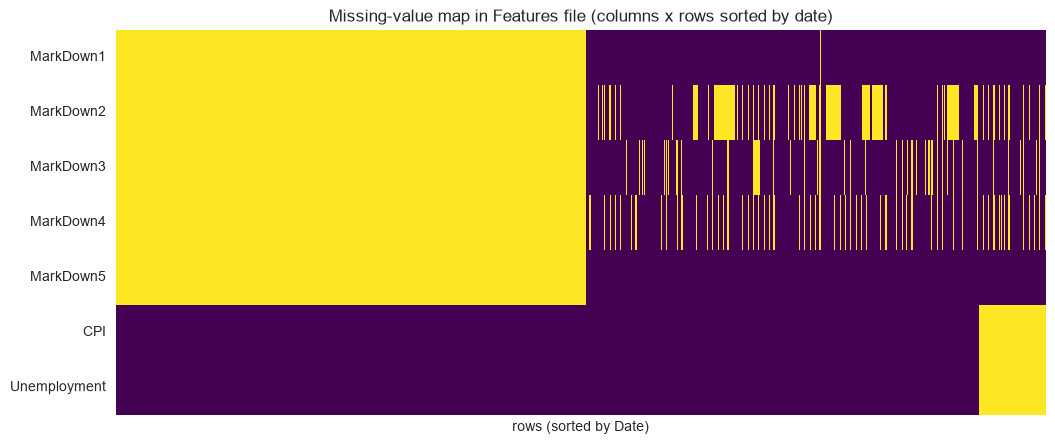

First week with any MarkDown value: 2011-11-11


In [8]:
# Visualizing the missing values
# Heatmap of NaNs in the features file, ordered by date, so the structural gap in MarkDowns is obvious.
f_sorted = features.sort_values(["Date","Store"])
plt.figure(figsize=(12, 5))
sns.heatmap(f_sorted[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5","CPI","Unemployment"]].isna().T,
            cbar=False, cmap="viridis", yticklabels=True, xticklabels=False)
plt.title("Missing-value map in Features file (columns x rows sorted by date)")
plt.xlabel("rows (sorted by Date)")
plt.show()

# When does MarkDown data start?
md_start = features.loc[features[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].notna().any(axis=1), "Date"].min()
print("First week with any MarkDown value:", md_start.date())

### What did you know about your dataset?

* Three relational tables are keyed on `Store` (+ `Date` for the weekly tables). `sales` has one row per **store × department × week**: 421,570 rows, 45 stores, 81 departments and 143 weekly dates from Feb-2010 to Oct-2012.
* `features` has one row per **store × week** and extends beyond the sales window, so the merge is correctly performed as a left join from sales. `stores` is a 45-row store master with `Type` and `Size`.
* Dates are in `dd/mm/yyyy` format and are parsed with `dayfirst=True`.
* No duplicate rows or duplicate Store-Department-Date sales keys were found.
* `MarkDown1–5` are structurally missing before Nov-2011 because the markdown programme had not yet started. This is not treated as random missingness.
* CPI and Unemployment are missing in the later tail of the feature file, but the sales-window merge is safeguarded with store-level filling.
* `Weekly_Sales` contains legitimate negative values (net returns) and large spikes, which are handled explicitly in the anomaly and outlier sections.
* `IsHoliday` appears in both weekly source tables and is used consistently in the merge.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print("sales   :", list(sales.columns))
print("features:", list(features.columns))
print("stores  :", list(stores.columns))

sales   : ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
features: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
stores  : ['Store', 'Type', 'Size']


In [10]:
# Dataset Describe
display(sales.describe().T)
display(features.describe().T)
display(stores.describe(include="all").T)

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519


,count,mean,min,25%,50%,75%,max,std
Store,8190.0,23.0,1.0,12.0,23.0,34.0,45.0,12.987966
Date,8190,2011-10-31 12:00:00,2010-02-05 00:00:00,2010-12-17 00:00:00,2011-10-31 12:00:00,2012-09-14 00:00:00,2013-07-26 00:00:00,NaN
Temperature,8190.0,59.356198,-7.29,45.9025,60.71,73.88,101.95,18.678607
Fuel_Price,8190.0,3.405992,2.472,3.041,3.513,3.743,4.468,0.431337
MarkDown1,4032.0,7032.371786,-2781.45,1577.5325,4743.58,8923.31,103184.98,9262.747448
MarkDown2,2921.0,3384.176594,-265.76,68.88,364.57,2153.35,104519.54,8793.583016
MarkDown3,3613.0,1760.10018,-179.26,6.6,36.26,163.15,149483.31,11276.462208
MarkDown4,3464.0,3292.935886,0.22,304.6875,1176.425,3310.0075,67474.85,6792.329861
MarkDown5,4050.0,4132.216422,-185.17,1440.8275,2727.135,4832.555,771448.1,13086.690278
CPI,7605.0,172.460809,126.064,132.364839,182.764003,213.932412,228.976456,39.738346


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Store,45.0,NaN,NaN,NaN,23.0,13.133926,1.0,12.0,23.0,34.0,45.0
Type,45,3,A,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,45.0,NaN,NaN,NaN,130287.6,63825.271991,34875.0,70713.0,126512.0,202307.0,219622.0


### Variables Description

| Table | Variable | Type | Meaning |
|---|---|---|---|
| sales | Store | int (1–45) | Store identifier |
| sales | Dept | int (1–99) | Department identifier (~81 distinct) |
| sales | Date | date | Week-ending date (Friday) |
| sales | Weekly_Sales | float | **Target** — sales for that store-dept-week (can be negative = net returns) |
| sales | IsHoliday | bool | Week contains a major holiday (Super Bowl, Labor Day, Thanksgiving, Christmas) |
| features | Temperature | float (°F) | Average regional temperature |
| features | Fuel_Price | float ($) | Regional fuel price |
| features | MarkDown1–5 | float ($) | Anonymised promotional markdowns; only available from Nov-2011 |
| features | CPI | float | Consumer Price Index (regional) |
| features | Unemployment | float (%) | Regional unemployment rate |
| stores | Type | category A/B/C | Store format (A = largest) |
| stores | Size | int (sq ft) | Store floor area |

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for name, d in dict(sales=sales, features=features, stores=stores).items():
    print(f"\n{name}:")
    print(d.nunique().to_string())
print("\nDate range (sales):", sales.Date.min().date(), "->", sales.Date.max().date(),
      "|", sales.Date.nunique(), "weeks")
print("Holiday weeks (sales):", sales.loc[sales.IsHoliday, "Date"].dt.date.unique())


sales:
Store               45
Dept                81
Date               143
Weekly_Sales    359464
IsHoliday            2

features:
Store             45
Date             182
Temperature     4178
Fuel_Price      1011
MarkDown1       4023
MarkDown2       2715
MarkDown3       2885
MarkDown4       3405
MarkDown5       4045
CPI             2505
Unemployment     404
IsHoliday          2

stores:
Store    45
Type      3
Size     40

Date range (sales): 2010-02-05 -> 2012-10-26 | 143 weeks
Holiday weeks (sales): [datetime.date(2010, 2, 12) datetime.date(2010, 9, 10)
 datetime.date(2010, 11, 26) datetime.date(2010, 12, 31)
 datetime.date(2011, 2, 11) datetime.date(2011, 9, 9)
 datetime.date(2011, 11, 25) datetime.date(2011, 12, 30)
 datetime.date(2012, 2, 10) datetime.date(2012, 9, 7)]


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1) Merge the three tables. Left join from sales keeps exactly the sales rows.
df = (sales
      .merge(features, on=["Store", "Date", "IsHoliday"], how="left")
      .merge(stores,   on="Store", how="left"))
assert len(df) == len(sales), "Row count changed during merge - check join keys."

# 2) Tidy dtypes
df["IsHoliday"] = df["IsHoliday"].astype(int)
df["Type"] = df["Type"].astype("category")
df = df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

# 3) Basic calendar features (used by charts; richer features are built in section 6)
df["Year"]  = df.Date.dt.year
df["Month"] = df.Date.dt.month
df["Week"]  = df.Date.dt.isocalendar().week.astype(int)
df["Quarter"] = df.Date.dt.quarter

# 4) Named holiday flags (dates from the original dataset documentation)
HOLIDAYS = {
    "SuperBowl":    ["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"],
    "LaborDay":     ["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"],
    "Thanksgiving": ["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"],
    "Christmas":    ["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"],
}
for h, dates in HOLIDAYS.items():
    df[f"Is_{h}"] = df.Date.isin(pd.to_datetime(dates)).astype(int)
df["Holiday_Name"] = "None"
for h in HOLIDAYS:
    df.loc[df[f"Is_{h}"] == 1, "Holiday_Name"] = h

# 5) Total / any-markdown helper (NaN kept for now; imputed in section 6)
md_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
df["Total_MarkDown"] = df[md_cols].sum(axis=1, min_count=1)   # NaN if all five are NaN

print(df.shape)
missing_report(df, "merged df")
display(df.head())

(421570, 26)

merged df:


,missing,pct
MarkDown1,270889,64.26
MarkDown2,310322,73.61
MarkDown3,284479,67.48
MarkDown4,286603,67.98
MarkDown5,270138,64.08
Total_MarkDown,270138,64.08


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Year,Month,Week,Quarter,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Holiday_Name,Total_MarkDown
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,...,2010,2,5,1,0,0,0,0,None,NaN
1,1,1,2010-02-12,46039.49,1,38.51,2.548,NaN,NaN,NaN,...,2010,2,6,1,1,0,0,0,SuperBowl,NaN
2,1,1,2010-02-19,41595.55,0,39.93,2.514,NaN,NaN,NaN,...,2010,2,7,1,0,0,0,0,None,NaN
3,1,1,2010-02-26,19403.54,0,46.63,2.561,NaN,NaN,NaN,...,2010,2,8,1,0,0,0,0,None,NaN
4,1,1,2010-03-05,21827.90,0,46.50,2.625,NaN,NaN,NaN,...,2010,3,9,1,0,0,0,0,None,NaN


### What all manipulations have you done and insights you found?

* Left-joined `sales ← features ← stores` on `Store`, `Date` and `IsHoliday`; the sales row count remains **421,570**.
* Converted `IsHoliday` to a 0/1 field and `Type` to a categorical variable; sorted data by Store → Department → Date to support temporal features.
* Added calendar fields and four named holiday flags: Super Bowl, Labor Day, Thanksgiving and Christmas.
* Created `Total_MarkDown` for exploratory analysis while leaving the original missingness visible until the preprocessing section.
* The merged data confirms that markdown missingness is the dominant data-quality issue; CPI/Unemployment are complete within the observed sales period after the merge.
* The named holiday variables reveal that holiday effects are not homogeneous, so the generic `IsHoliday` flag alone is not sufficient for business interpretation.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

*Charts follow the UBM rule: 1–4 univariate, 5–11 bivariate, 12–15 multivariate/time-series.*

#### Chart - 1 - Distribution of Weekly_Sales (Univariate)

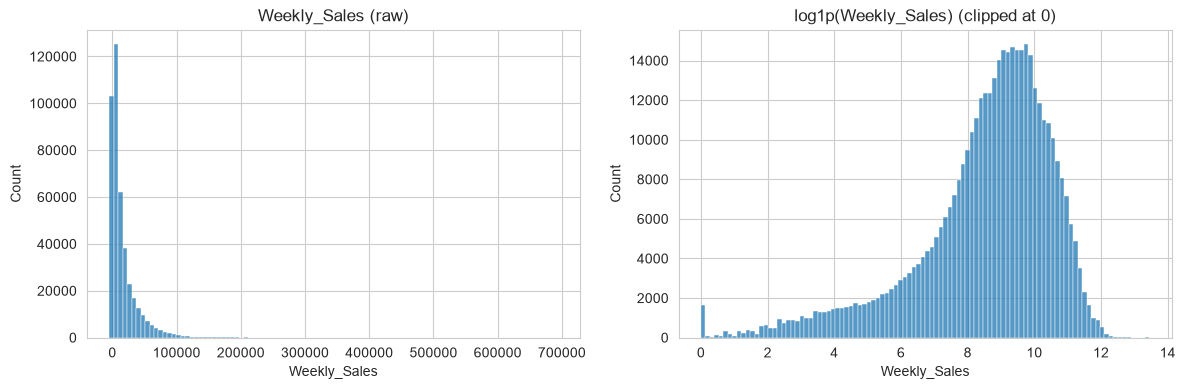

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64
Negative-sales rows: 1285 | Zero-sales rows: 73


In [13]:
# Chart - 1 visualization code
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["Weekly_Sales"], bins=100, ax=ax[0]); ax[0].set_title("Weekly_Sales (raw)")
sns.histplot(np.log1p(df["Weekly_Sales"].clip(lower=0)), bins=100, ax=ax[1]); ax[1].set_title("log1p(Weekly_Sales) (clipped at 0)")
plt.show()
print(df["Weekly_Sales"].describe())
print("Negative-sales rows:", (df.Weekly_Sales < 0).sum(), "| Zero-sales rows:", (df.Weekly_Sales == 0).sum())

##### 1. Why did you pick the specific chart?

The target drives every model; a histogram (raw + log) exposes skew, the long right tail and the presence of negative values, which dictates transformation and outlier strategy.

##### 2. What is/are the insight(s) found from the chart?

The target is extremely right-skewed. Median weekly sales are **7,612**, while the mean is **15,981**, and the maximum reaches **693,099**. There are **1,285 negative-sales rows** and 73 zero-sales rows. The log view is much more compact, confirming that a transformation is useful for the linear baseline while raw values should be preserved for business interpretation and tree models.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The skew and extreme peaks show why a single global average is unsuitable for inventory planning. Retaining negative values also prevents genuine return weeks from being incorrectly deleted. The main risk is that extreme holiday/promotion weeks can dominate ordinary-loss functions, which motivates robust treatment and holiday-aware evaluation.

#### Chart - 2 - Store Type & Size (Univariate)

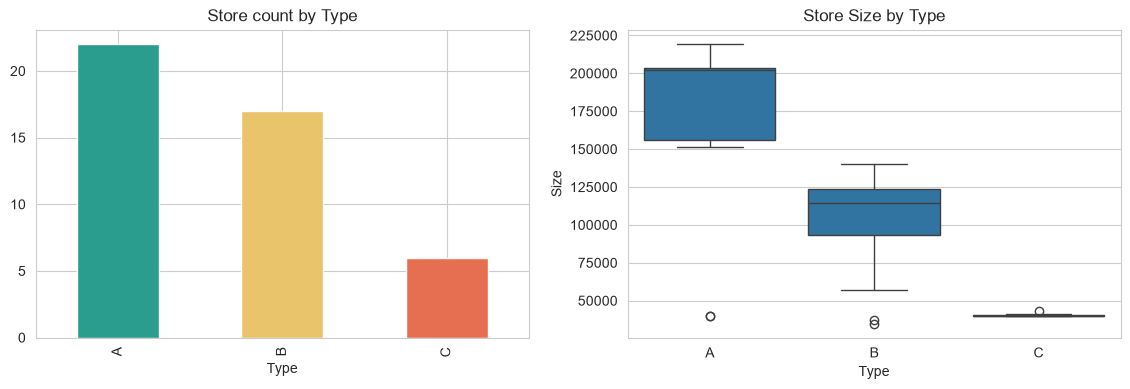

,count,mean,min,max
Type,,,,
A,22,177247.727273,39690,219622
B,17,101190.705882,34875,140167
C,6,40541.666667,39690,42988


In [14]:
# Chart - 2 visualization code
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
stores["Type"].value_counts().plot.bar(ax=ax[0], color=["#2a9d8f","#e9c46a","#e76f51"]); ax[0].set_title("Store count by Type")
sns.boxplot(data=stores, x="Type", y="Size", ax=ax[1]); ax[1].set_title("Store Size by Type")
plt.show()
display(stores.groupby("Type")["Size"].agg(["count","mean","min","max"]))

##### 1. Why did you pick the specific chart?

Type and Size are the only static store attributes; showing their joint distribution tells us whether Type is essentially a size bucket (and hence redundant) before we use it in segmentation.

##### 2. What is/are the insight(s) found from the chart?

Store format is strongly associated with physical size. Type A has **22 stores** with mean size ≈ **177,248 sq ft**, Type B has 17 stores with mean ≈ **101,191 sq ft**, and Type C has 6 stores with mean ≈ **40,542 sq ft**. The boxplots show clear separation, although a few size outliers exist.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Store type/size can guide differentiated capacity, assortment and staffing decisions. It also warns against treating Type and Size as independent signals without checking redundancy, which is important for model simplification and segmentation.

#### Chart - 3 - Distribution of External Factors (Univariate)

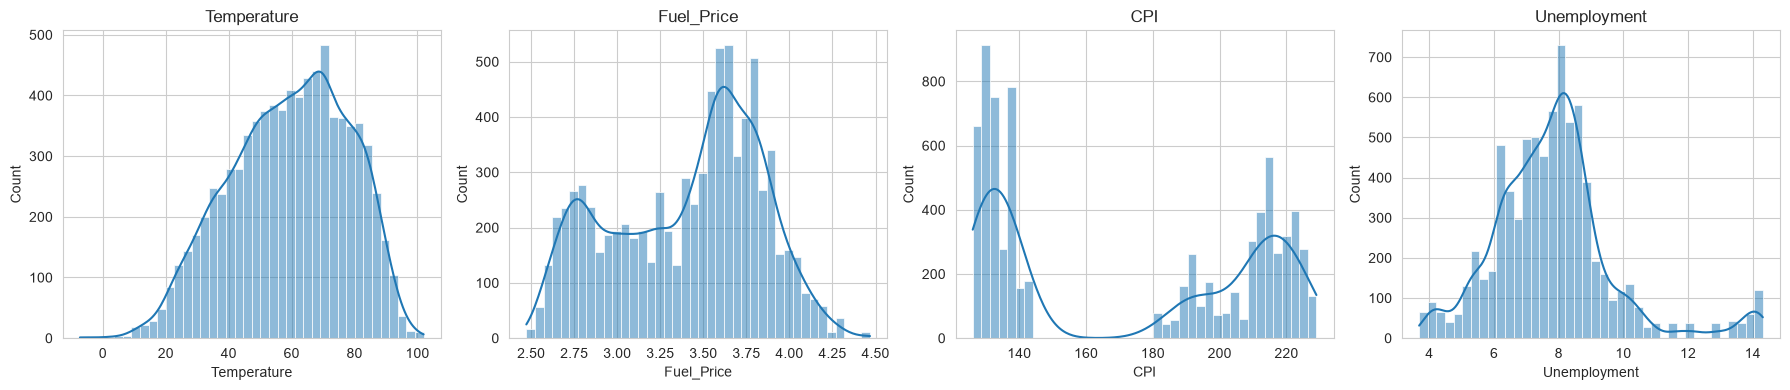

In [15]:
# Chart - 3 visualization code
ext = ["Temperature","Fuel_Price","CPI","Unemployment"]
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for i, c in enumerate(ext):
    sns.histplot(features[c].dropna(), bins=40, ax=ax[i], kde=True); ax[i].set_title(c)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

The four macro/regional drivers have very different scales and shapes (CPI is bimodal across regions, unemployment is right-skewed). Knowing this justifies scaling and tells us CPI behaves like a regional label more than a time signal.

##### 2. What is/are the insight(s) found from the chart?

The four external variables have very different distributions and scales. CPI is clearly multi-modal across regional groups, unemployment is right-skewed, fuel prices vary over a narrower band, and temperature spans a wide seasonal range. These variables therefore behave partly as regional/contextual indicators rather than simple linear demand drivers.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The distributions justify scaling for distance/linear methods and support segment-level economic analysis. However, their regional structure means that raw correlations should not automatically be interpreted as causal economic effects.

#### Chart - 4 - MarkDown availability and magnitude (Univariate)

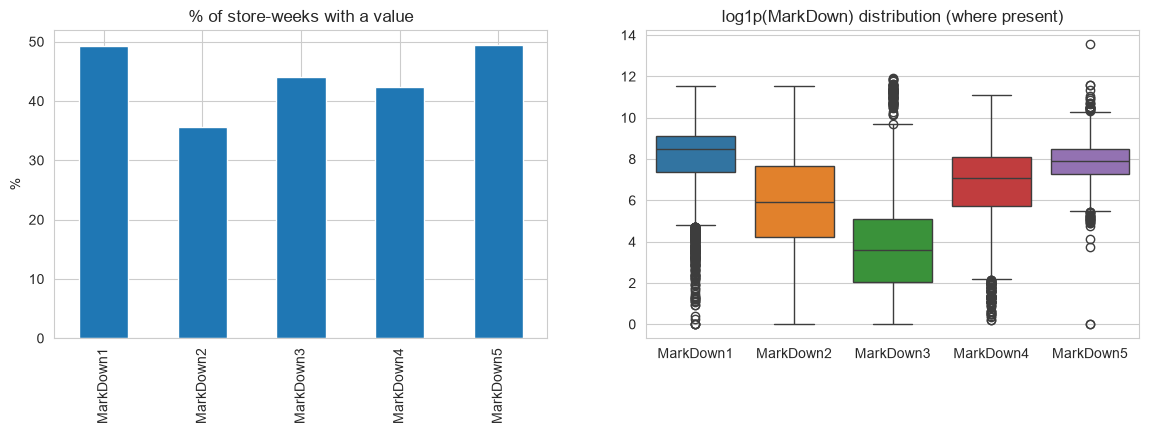

In [16]:
# Chart - 4 visualization code
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
(features[md_cols].notna().mean()*100).plot.bar(ax=ax[0]); ax[0].set_title("% of store-weeks with a value"); ax[0].set_ylabel("%")
sns.boxplot(data=np.log1p(features[md_cols].clip(lower=0)), ax=ax[1]); ax[1].set_title("log1p(MarkDown) distribution (where present)")
plt.show()

##### 1. Why did you pick the specific chart?

Markdowns are the main lever the business controls, but 64% are missing. Quantifying availability and scale per series decides the imputation approach and whether markdowns can be used for all periods or only Nov-2011 onward.

##### 2. What is/are the insight(s) found from the chart?

Markdown availability is incomplete and uneven: roughly **35%–50%** of store-weeks contain values depending on the markdown field. The observed markdown amounts are also highly skewed, with several large upper-tail values. This agrees with the earlier finding that markdown data only begins in Nov-2011.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Treating missing markdowns as ordinary random missing values would invent promotions that did not occur. Using zero plus an availability indicator preserves the business meaning and avoids dropping a large part of the sales history. The skew also supports robust/nonlinear modelling rather than simple linear assumptions.

#### Chart - 5 - Average Weekly Sales by Store (Bivariate: Cat–Num)

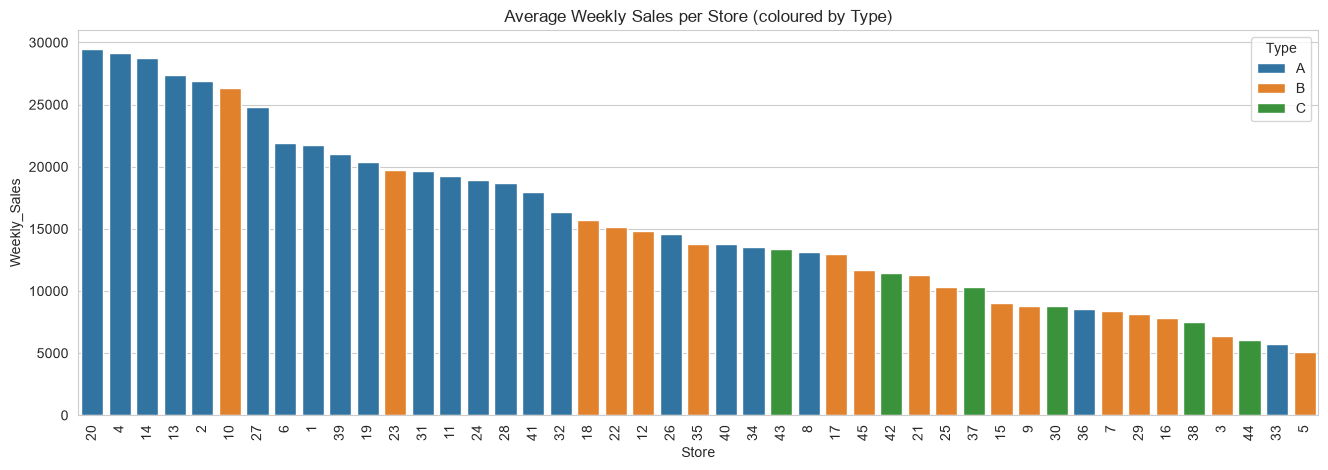

In [17]:
# Chart - 5 visualization code
store_avg = df.groupby(["Store","Type"], observed=True)["Weekly_Sales"].mean().reset_index().sort_values("Weekly_Sales", ascending=False)
plt.figure(figsize=(16, 5))
sns.barplot(data=store_avg, x="Store", y="Weekly_Sales", hue="Type", dodge=False, order=store_avg.Store)
plt.title("Average Weekly Sales per Store (coloured by Type)"); plt.xticks(rotation=90); plt.show()

##### 1. Why did you pick the specific chart?

A ranked bar chart identifies the revenue concentration across stores and whether Type explains the ranking — the first hint of natural store segments.

##### 2. What is/are the insight(s) found from the chart?

Average weekly sales differ substantially by store. The highest-ranked stores are predominantly **Type A**, while lower-ranked stores contain more Type B/C locations, although store type does not perfectly determine the ranking. This indicates meaningful store-level heterogeneity beyond the A/B/C label.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. High-volume stores can receive tighter replenishment monitoring and larger absolute safety-stock budgets, while lower-volume stores require leaner planning. The overlap between store types also motivates the later behavioural segmentation instead of relying only on the original Type label.

#### Chart - 6 - Average Weekly Sales by Department (Bivariate: Cat–Num)

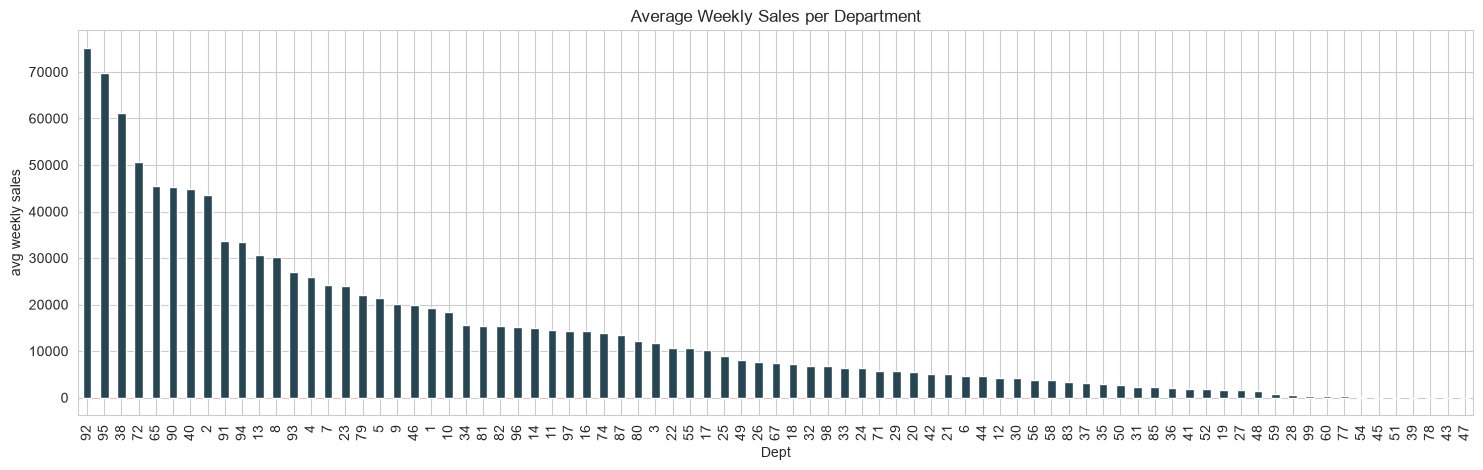

Top-10 departments share of total sales: 43.1%


In [18]:
# Chart - 6 visualization code
dept_avg = df.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False)
plt.figure(figsize=(18, 5))
dept_avg.plot.bar(color="#264653")
plt.title("Average Weekly Sales per Department"); plt.ylabel("avg weekly sales"); plt.show()
print("Top-10 departments share of total sales: {:.1%}".format(
    df[df.Dept.isin(dept_avg.head(10).index)].Weekly_Sales.sum() / df.Weekly_Sales.sum()))

##### 1. Why did you pick the specific chart?

Departments are the unit of the market-basket and much of the forecasting difficulty; a Pareto-style view shows how concentrated sales are and which departments deserve tighter forecasts.

##### 2. What is/are the insight(s) found from the chart?

Department demand is highly concentrated: the **top 10 departments account for 43.1% of total sales**. A small group of departments has much higher average weekly sales than the long tail of lower-volume departments.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Forecasting accuracy and replenishment effort should be prioritised for the high-volume departments because an error there has larger financial impact. The long tail can use simpler/leaner policies, while high-volume departments deserve tighter service-level and anomaly monitoring.

#### Chart - 7 - Holiday vs Non-holiday sales, by named holiday (Bivariate: Cat–Num)

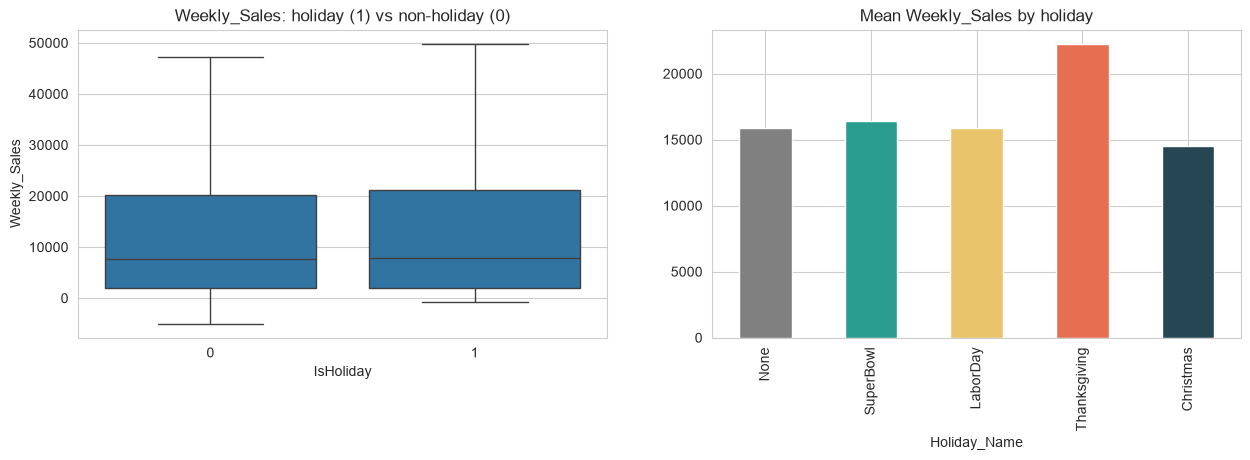

Holiday_Name
None            0.000
SuperBowl       0.030
LaborDay       -0.001
Thanksgiving    0.397
Christmas      -0.085
Name: uplift vs non-holiday, dtype: float64


In [19]:
# Chart - 7 visualization code
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(data=df, x="IsHoliday", y="Weekly_Sales", showfliers=False, ax=ax[0]); ax[0].set_title("Weekly_Sales: holiday (1) vs non-holiday (0)")
hol = df.groupby("Holiday_Name")["Weekly_Sales"].mean().reindex(["None","SuperBowl","LaborDay","Thanksgiving","Christmas"])
hol.plot.bar(ax=ax[1], color=["grey","#2a9d8f","#e9c46a","#e76f51","#264653"]); ax[1].set_title("Mean Weekly_Sales by holiday")
plt.show()
print((hol / hol["None"] - 1).round(3).rename("uplift vs non-holiday"))

##### 1. Why did you pick the specific chart?

The brief asks explicitly about holiday effects. Splitting the generic flag into named holidays reveals that they are *not* interchangeable — essential for the anomaly interpretation and for weighting holidays in the forecast metric.

##### 2. What is/are the insight(s) found from the chart?

Holiday effects are very different by event. Relative to non-holiday weeks, average sales are about **+39.7% at Thanksgiving**, **+3.0% at Super Bowl**, approximately flat at Labor Day (**-0.1%**), and **-8.5% for the Christmas-labelled week** in this calendar definition. A single holiday flag therefore hides materially different patterns.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Thanksgiving requires substantially more inventory capacity, while Labor Day should not automatically receive the same uplift. The negative Christmas-labelled result also highlights calendar alignment: the dataset's holiday-week definition can fall after the main pre-Christmas shopping surge, so operational interpretation must use the named date correctly.

#### Chart - 8 - Store Size vs Average Sales (Bivariate: Num–Num)

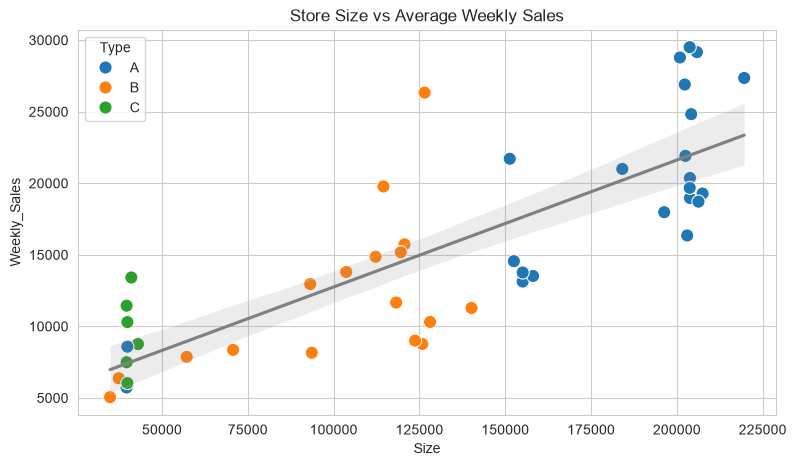

Pearson r(Size, avg sales) = 0.807


In [20]:
# Chart - 8 visualization code
sz = df.groupby(["Store","Type","Size"], observed=True)["Weekly_Sales"].mean().reset_index()
plt.figure(figsize=(9, 5))
sns.scatterplot(data=sz, x="Size", y="Weekly_Sales", hue="Type", s=90)
sns.regplot(data=sz, x="Size", y="Weekly_Sales", scatter=False, color="grey")
plt.title("Store Size vs Average Weekly Sales"); plt.show()
print("Pearson r(Size, avg sales) = {:.3f}".format(sz[["Size","Weekly_Sales"]].corr().iloc[0,1]))

##### 1. Why did you pick the specific chart?

Size is the strongest static predictor candidate; a scatter with a fitted line quantifies how linear the relationship is and exposes over/under-performing stores relative to their footprint (store-optimisation targets).

##### 2. What is/are the insight(s) found from the chart?

Store size and average weekly sales have a strong positive relationship: **Pearson r = 0.807**. Larger stores generally sell more, but the scatter also shows stores that sit above or below the fitted trend, indicating different productivity relative to floor area.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Size is a strong planning signal, while deviations from the size-sales trend can identify potential over/under-performing stores. Stores below their peer trend may need assortment/floor-space review; stores above it may indicate high productivity or capacity pressure.

#### Chart - 9 - Sales vs Economic indicators (Bivariate: Num–Num)

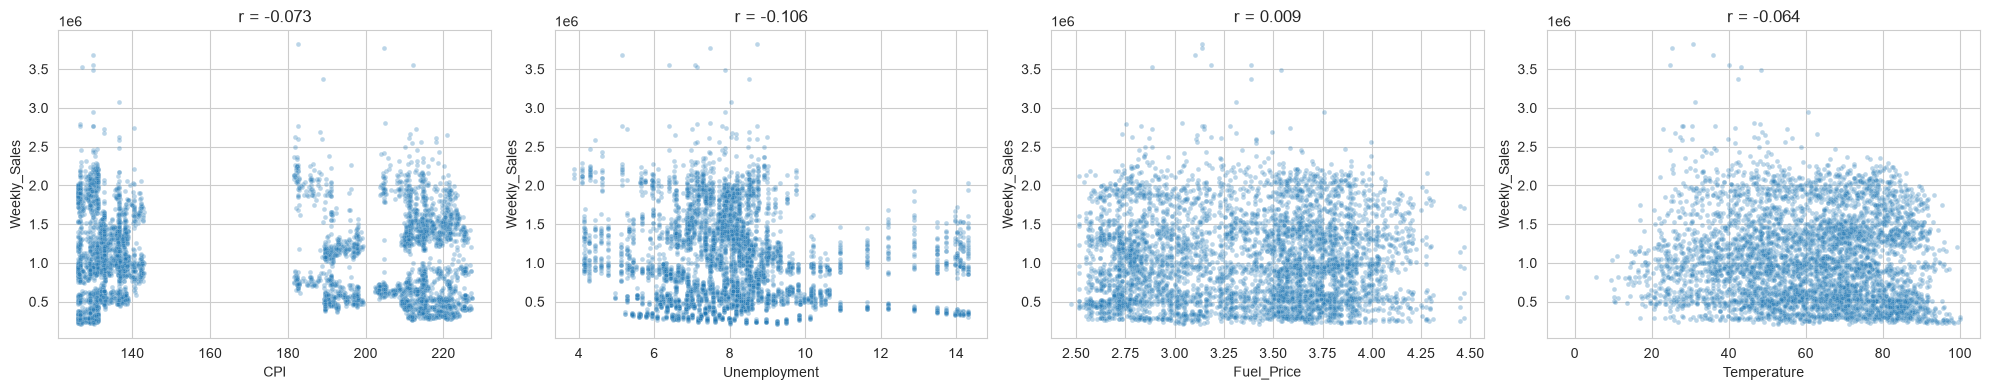

In [21]:
# Chart - 9 visualization code
# Aggregate to store-week level first so each point is an actual store-week, not a department row.
sw = df.groupby(["Store","Date"]).agg(Weekly_Sales=("Weekly_Sales","sum"), CPI=("CPI","first"),
                                       Unemployment=("Unemployment","first"), Fuel_Price=("Fuel_Price","first"),
                                       Temperature=("Temperature","first")).reset_index()
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for i, c in enumerate(["CPI","Unemployment","Fuel_Price","Temperature"]):
    sns.scatterplot(data=sw.sample(min(5000, len(sw)), random_state=RANDOM_STATE), x=c, y="Weekly_Sales", alpha=.3, s=12, ax=ax[i])
    ax[i].set_title(f"r = {sw[[c,'Weekly_Sales']].corr().iloc[0,1]:.3f}")
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

The brief weights 'impact of external factors' at 10%; raw scatter plots at store-week level are the honest first look at whether CPI, unemployment, fuel and temperature relate to sales *across* stores.

##### 2. What is/are the insight(s) found from the chart?

At store-week level, simple linear relationships with total sales are weak: **CPI r = -0.073**, **Unemployment r = -0.106**, **Fuel Price r = 0.009**, and **Temperature r = -0.064**. The visible store bands show that location/store effects dominate these raw pairwise relationships.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, mainly as a caution. Macro variables may still help within store/segment or through nonlinear interactions, but the weak pooled correlations show that they should not be treated as dominant standalone demand drivers. Their incremental value is tested formally later through feature importance and ablation.

#### Chart - 10 - Markdown intensity vs Sales (Bivariate: Num–Num, post Nov-2011)

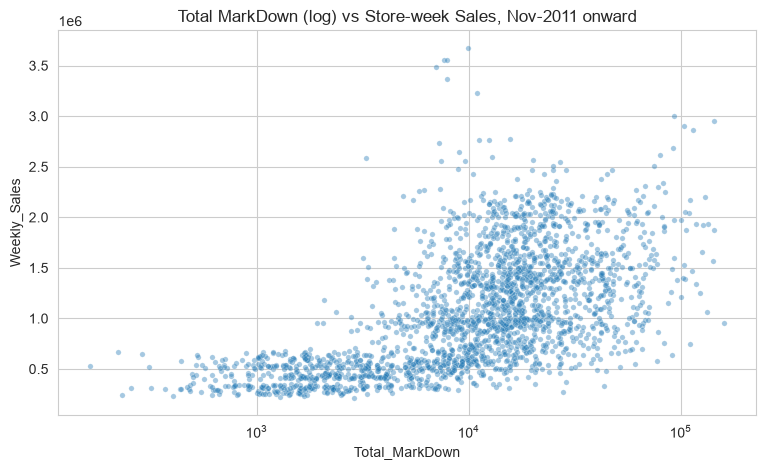

Spearman rho = 0.639


In [22]:
# Chart - 10 visualization code
post = df[df.Date >= "2011-11-01"].groupby(["Store","Date"]).agg(Weekly_Sales=("Weekly_Sales","sum"),
                                                                 Total_MarkDown=("Total_MarkDown","first")).dropna()
plt.figure(figsize=(9, 5))
sns.scatterplot(data=post, x="Total_MarkDown", y="Weekly_Sales", alpha=.4, s=15)
plt.xscale("log"); plt.title("Total MarkDown (log) vs Store-week Sales, Nov-2011 onward"); plt.show()
print("Spearman rho =", round(stats.spearmanr(post.Total_MarkDown, post.Weekly_Sales).correlation, 3))

##### 1. Why did you pick the specific chart?

Markdowns are the controllable marketing lever; restricting to the period where they exist and using a log scale (they are heavy-tailed) shows whether bigger markdowns coincide with bigger sales weeks.

##### 2. What is/are the insight(s) found from the chart?

After markdown data becomes available, markdown intensity has a clear positive monotonic association with store-week sales: **Spearman ρ = 0.639**. High-markdown weeks often coincide with high-sales weeks, although the scatter remains broad.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Markdown intensity is a useful promotion-context feature and can help identify high-response periods. The relationship is associative rather than causal: larger markdowns may be scheduled precisely because high-volume holiday periods are expected, so the analysis should not equate correlation with promotional lift.

#### Chart - 11 - Holiday share by Store Type (Bivariate: Cat–Cat)

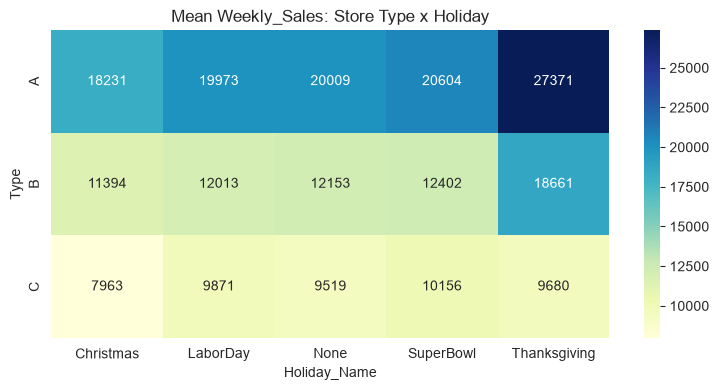

In [23]:
# Chart - 11 visualization code
ct = pd.crosstab(df["Type"], df["Holiday_Name"], values=df["Weekly_Sales"], aggfunc="mean").round(0)
plt.figure(figsize=(9, 4))
sns.heatmap(ct, annot=True, fmt=".0f", cmap="YlGnBu"); plt.title("Mean Weekly_Sales: Store Type x Holiday"); plt.show()

##### 1. Why did you pick the specific chart?

A categorical × categorical heatmap checks whether holiday response differs by store format — if it does, holiday inventory planning must be segment-specific.

##### 2. What is/are the insight(s) found from the chart?

Thanksgiving produces the clearest uplift for Types A and B: mean weekly sales rise to about **27,371** for Type A and **18,661** for Type B versus non-holiday means of about 20,009 and 12,153 respectively. Type C shows much less Thanksgiving uplift (≈9,680 versus ≈9,519 normally). Holiday response therefore differs by store format.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Holiday inventory and promotion policies should be differentiated by store segment/type rather than applied chain-wide. Large Type A/B stores need stronger Thanksgiving preparation, while the same uplift assumption would over-stock some smaller Type C locations.

#### Chart - 12 - Total chain weekly sales over time with holidays (Time-series / Multivariate)

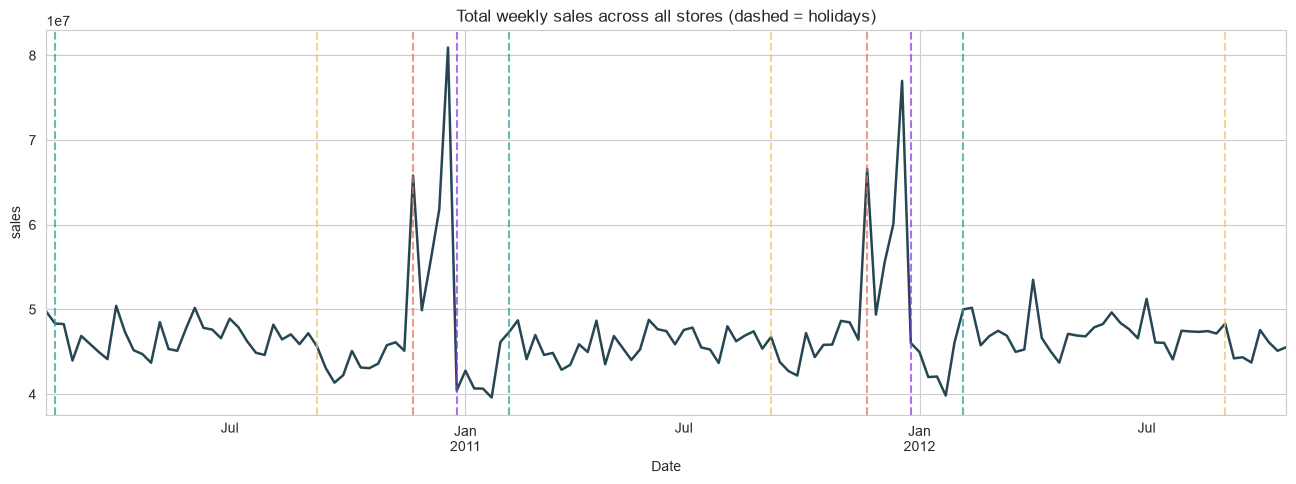

In [24]:
# Chart - 12 visualization code
ts = df.groupby("Date")["Weekly_Sales"].sum()
plt.figure(figsize=(16, 5))
ts.plot(color="#264653", lw=1.8)
for h, dates in HOLIDAYS.items():
    for d in pd.to_datetime(dates):
        if ts.index.min() <= d <= ts.index.max():
            plt.axvline(d, color={"SuperBowl":"#2a9d8f","LaborDay":"#e9c46a","Thanksgiving":"#e76f51","Christmas":"#8338ec"}[h], ls="--", alpha=.7)
plt.title("Total weekly sales across all stores (dashed = holidays)"); plt.ylabel("sales"); plt.show()

##### 1. Why did you pick the specific chart?

The core time-based view: it makes the yearly seasonality, the Thanksgiving/Christmas peaks and the January trough visible, motivating lag-52 features and time-based anomaly detection.

##### 2. What is/are the insight(s) found from the chart?

Chain sales show repeated annual seasonality with pronounced year-end spikes, especially around the Thanksgiving/Christmas period, followed by lower post-holiday weeks. Similar peak shapes recur across years, supporting explicit seasonal and lag-based forecasting features.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The recurring pattern supports advance inventory positioning before predictable peak weeks and motivates a chronological forecasting split. It also helps distinguish expected seasonal peaks from true anomalies, reducing unnecessary operational alerts.

#### Chart - 13 - Seasonal decomposition of chain sales (Time-series)

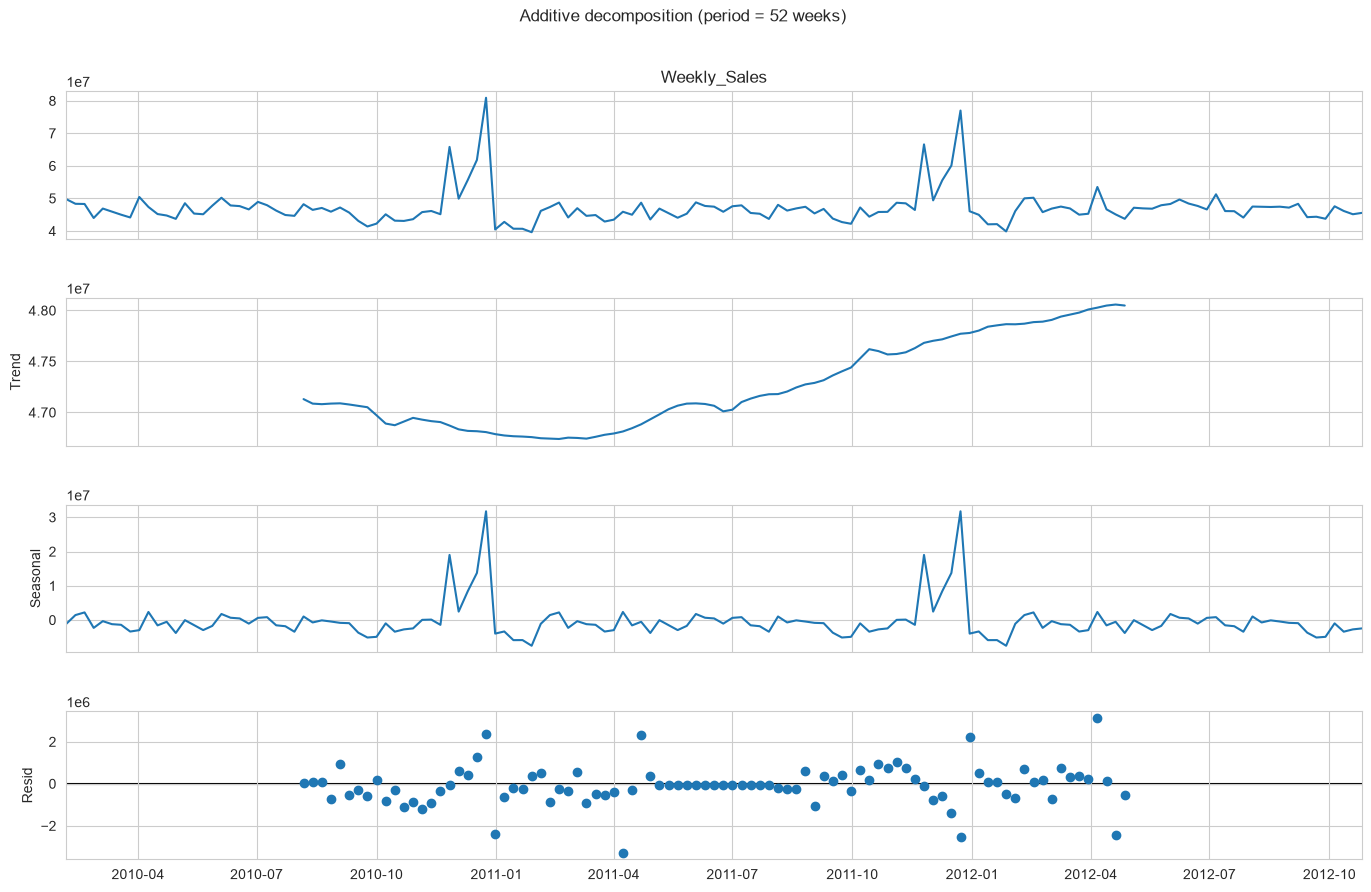

ADF statistic = -5.908, p-value = 0.0000  ->  stationary


In [25]:
# Chart - 13 visualization code
dec = seasonal_decompose(ts, model="additive", period=52)
fig = dec.plot(); fig.set_size_inches(14, 9); plt.suptitle("Additive decomposition (period = 52 weeks)", y=1.02); plt.show()
adf = adfuller(ts.dropna())
print(f"ADF statistic = {adf[0]:.3f}, p-value = {adf[1]:.4f}  ->  {'stationary' if adf[1] < 0.05 else 'non-stationary'}")

##### 1. Why did you pick the specific chart?

Decomposition separates trend, seasonality and residual; the residual panel is exactly where time-based anomalies live, and the ADF test decides how the SARIMA model must be differenced.

##### 2. What is/are the insight(s) found from the chart?

The decomposition separates a slowly changing trend, a strong repeating **52-week seasonal component**, and residual shocks. The ADF test gives **statistic = -5.908, p < 0.001**, so the aggregate weekly series is statistically stationary under this test despite its visible seasonal structure.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The seasonal component validates the use of annual seasonality in both feature engineering and SARIMA. Residual spikes provide a cleaner anomaly signal after expected seasonality is removed, improving alert quality and long-range planning.

#### Chart - 14 - Correlation Heatmap (Multivariate)

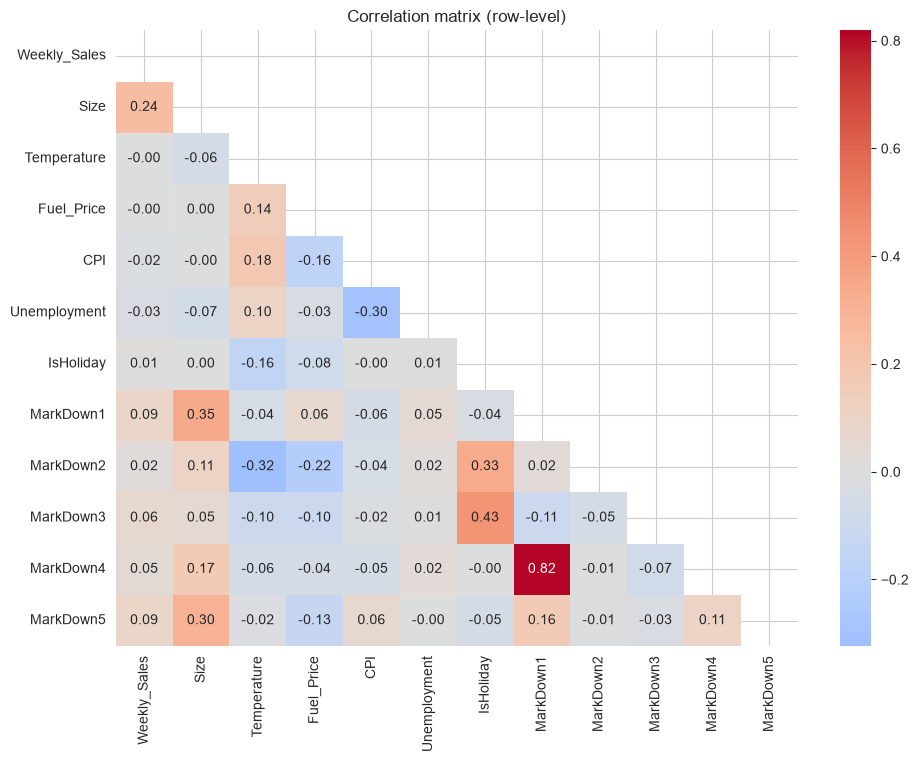

In [26]:
# Correlation Heatmap visualization code
num_cols = ["Weekly_Sales","Size","Temperature","Fuel_Price","CPI","Unemployment","IsHoliday"] + md_cols
corr = df[num_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, mask=np.triu(np.ones_like(corr, bool)))
plt.title("Correlation matrix (row-level)"); plt.show()

##### 1. Why did you pick the specific chart?

One view of all pairwise linear relationships: identifies multicollinearity among markdowns (relevant for the linear model) and confirms which drivers correlate with the target at all.

##### 2. What is/are the insight(s) found from the chart?

At row level, `Weekly_Sales` has its largest displayed linear correlation with **Size (0.24)**; direct correlations with CPI, unemployment, fuel price and temperature are near zero. The strongest relationship in the matrix is between **MarkDown1 and MarkDown4 (0.82)**, showing substantial multicollinearity among promotion variables. Several markdown fields also correlate moderately with store Size.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The heatmap supports correlation-based feature pruning and shows why external factors are unlikely to dominate a weekly sales model on their own. High markdown multicollinearity can make linear coefficients unstable, while tree-based models are better able to handle interacting promotion signals.

#### Chart - 15 - Pair Plot of store-level profile (Multivariate)

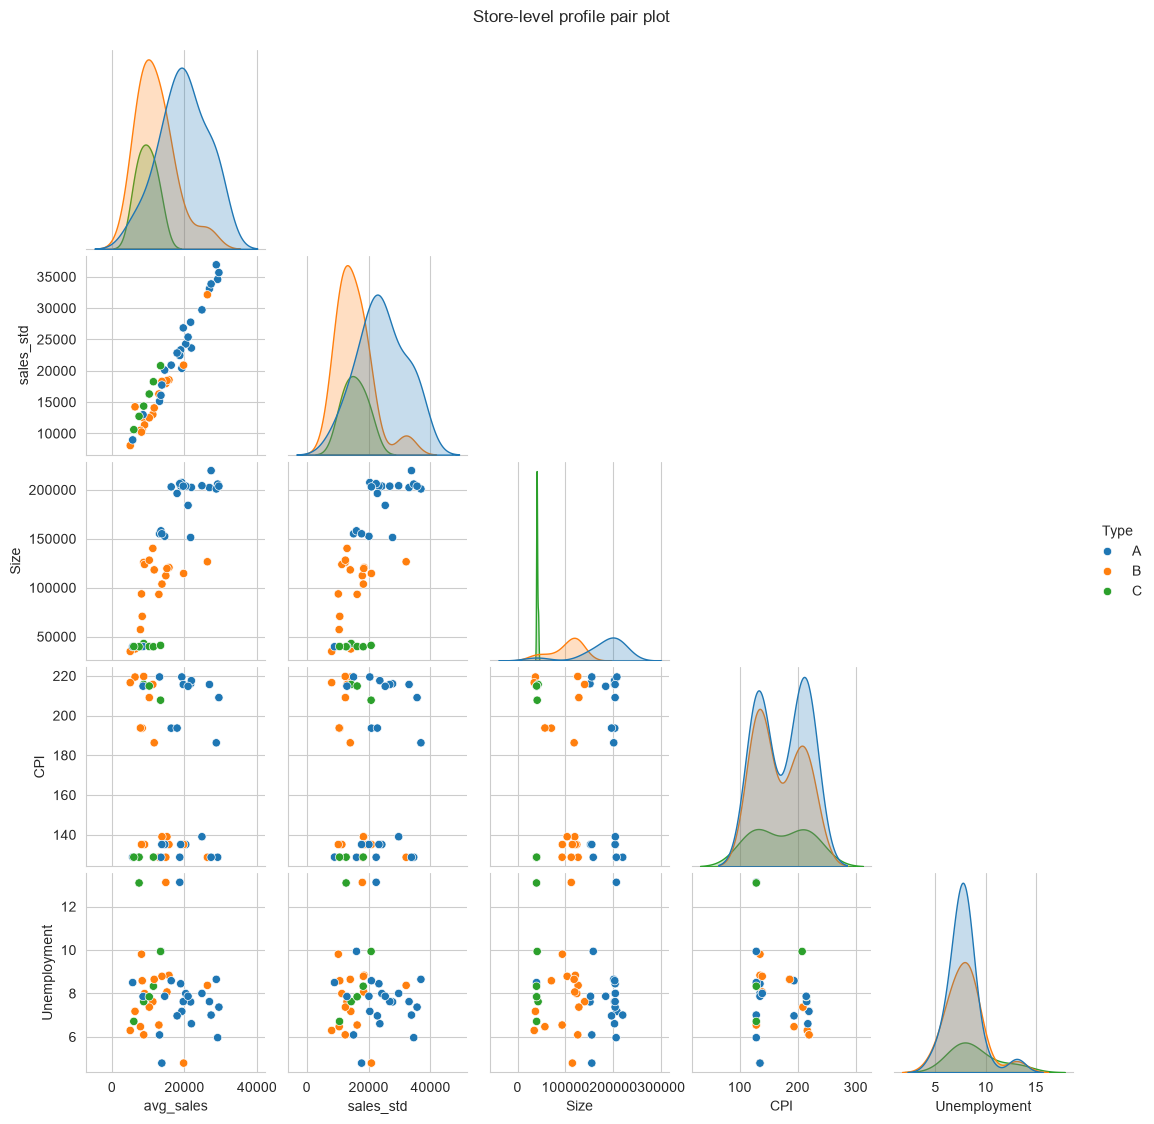

In [27]:
# Pair Plot visualization code
prof = df.groupby(["Store","Type"], observed=True).agg(
    avg_sales=("Weekly_Sales","mean"), sales_std=("Weekly_Sales","std"),
    Size=("Size","first"), CPI=("CPI","mean"), Unemployment=("Unemployment","mean")).reset_index()
sns.pairplot(prof, vars=["avg_sales","sales_std","Size","CPI","Unemployment"], hue="Type", height=2.2, corner=True)
plt.suptitle("Store-level profile pair plot", y=1.02); plt.show()

##### 1. Why did you pick the specific chart?

Segmentation happens at store level, so a pair plot of the store-level profile (45 points) previews the cluster structure and whether Type already separates the stores.

##### 2. What is/are the insight(s) found from the chart?

The store-level pair plot shows that **Size, average sales and sales volatility** separate store Types much more clearly than CPI or unemployment. Type A stores cluster toward larger size/higher sales, Type C toward smaller/lower sales, while Type B occupies the middle with overlap. This suggests real cluster structure but also room to improve on the original Type labels using behaviour and economic context.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The visible separation supports store segmentation and indicates that differentiated planning policies are more appropriate than one chain-wide rule. Because the groups overlap, clustering on multiple scaled features can capture information not contained in Type alone.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. **Holiday weeks have higher weekly sales than non-holiday weeks.**
2. **Mean weekly sales differ across store Types (A, B, C).**
3. **Unemployment rate is negatively associated with store-week sales (external-factor impact).**

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **H₀:** μ(holiday weekly sales) = μ(non-holiday weekly sales)
* **H₁:** μ(holiday weekly sales) > μ(non-holiday weekly sales)  (one-sided)

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
hol_s  = df.loc[df.IsHoliday == 1, "Weekly_Sales"]
nhol_s = df.loc[df.IsHoliday == 0, "Weekly_Sales"]
t, p_two = stats.ttest_ind(hol_s, nhol_s, equal_var=False)      # Welch's t-test (unequal variances / sizes)
p_one = p_two / 2 if t > 0 else 1 - p_two / 2
u, p_mw = stats.mannwhitneyu(hol_s, nhol_s, alternative="greater")  # non-parametric cross-check (data is skewed)
print(f"Welch t = {t:.3f}, one-sided p = {p_one:.2e}")
print(f"Mann-Whitney U p = {p_mw:.2e}")
print("Reject H0" if p_one < 0.05 else "Fail to reject H0")

Welch t = 7.001, one-sided p = 1.30e-12
Mann-Whitney U p = 1.31e-04
Reject H0


##### Which statistical test have you done to obtain P-Value?

Welch's two-sample t-test (one-sided), cross-checked with the Mann-Whitney U test.

**Result:** Welch t = **7.001**, one-sided p = **1.30×10⁻¹²**; Mann-Whitney p = **1.31×10⁻⁴**. Therefore, **H₀ is rejected** and holiday-week sales are statistically higher in this sample.

##### Why did you choose the specific statistical test?

The comparison contains two independent groups with unequal sample sizes and potentially unequal variances, so Welch's t-test is more appropriate than the equal-variance t-test. Because `Weekly_Sales` is strongly skewed, the rank-based Mann-Whitney test is used as a non-parametric robustness check.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **H₀:** Mean weekly sales are equal for store Types A, B and C.
* **H₁:** At least one store Type has a different mean weekly sales.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
groups = [g["Weekly_Sales"].values for _, g in df.groupby("Type", observed=True)]
f, p_anova = stats.f_oneway(*groups)
h, p_kw = stats.kruskal(*groups)
print(f"One-way ANOVA F = {f:.2f}, p = {p_anova:.2e}")
print(f"Kruskal-Wallis H = {h:.2f}, p = {p_kw:.2e}")
print("Reject H0" if p_anova < 0.05 else "Fail to reject H0")
# Post-hoc: which pairs differ?
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    print(pairwise_tukeyhsd(df["Weekly_Sales"], df["Type"].astype(str)))
except Exception as e:
    print("Tukey HSD skipped:", e)

One-way ANOVA F = 7764.43, p = 0.00e+00
Kruskal-Wallis H = 22878.85, p = 0.00e+00
Reject H0
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj    lower       upper    reject
--------------------------------------------------------------
     A      B  -7862.4921   0.0  -8033.9424  -7691.0417   True
     A      C -10580.0355   0.0 -10857.2206 -10302.8504   True
     B      C  -2717.5434   0.0  -3001.9088  -2433.1781   True
--------------------------------------------------------------


##### Which statistical test have you done to obtain P-Value?

One-way ANOVA with Tukey HSD post-hoc analysis, cross-checked with Kruskal-Wallis.

**Result:** ANOVA F = **7,764.43**, p < **0.001**; Kruskal-Wallis H = **22,878.85**, p < **0.001**. **H₀ is rejected.** Tukey HSD also finds significant differences for A–B, A–C and B–C store-type pairs.

##### Why did you choose the specific statistical test?

There are three independent categorical groups (store Types A, B and C) and one numeric outcome. ANOVA tests whether at least one mean differs; Kruskal-Wallis provides a distribution-free robustness check, and Tukey HSD identifies the specific pairs that differ.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **H₀:** ρ(Unemployment, store-week sales) = 0
* **H₁:** ρ(Unemployment, store-week sales) < 0

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
# Use store-week totals (sw from chart 9) and control for store size by using sales per sq ft.
sw2 = sw.merge(stores[["Store","Size"]], on="Store")
sw2["sales_per_sqft"] = sw2.Weekly_Sales / sw2.Size
rho, p_sp = stats.spearmanr(sw2.Unemployment, sw2.sales_per_sqft, alternative="less")
r,   p_pe = stats.pearsonr(sw2.Unemployment, sw2.sales_per_sqft)
print(f"Spearman rho = {rho:.3f}, one-sided p = {p_sp:.2e}")
print(f"Pearson r    = {r:.3f}, two-sided p = {p_pe:.2e}")
print("Reject H0" if p_sp < 0.05 else "Fail to reject H0")

Spearman rho = 0.015, one-sided p = 8.80e-01
Pearson r    = 0.028, two-sided p = 2.62e-02
Fail to reject H0


##### Which statistical test have you done to obtain P-Value?

Spearman rank correlation (one-sided), with Pearson correlation reported for reference.

**Result:** Spearman ρ = **0.015**, one-sided p = **0.880**; therefore, **H₀ is not rejected** for the hypothesised negative relationship. Pearson r = **0.028** (two-sided p = 0.026), which is statistically small and positive rather than negative.

##### Why did you choose the specific statistical test?

Both variables are continuous, but sales are heavy-tailed and the relationship need not be linear. Spearman correlation is therefore the primary test. Sales are normalised by store size so that the very strong store-size effect does not dominate the economic-factor comparison.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation
# MarkDowns: missing == "no markdown ran that week" (programme started Nov-2011). Impute 0 and keep an indicator.
df["MarkDown_Available"] = df[md_cols].notna().any(axis=1).astype(int)
df[md_cols] = df[md_cols].fillna(0)
df["Total_MarkDown"] = df[md_cols].sum(axis=1)
df["Has_MarkDown"] = (df["Total_MarkDown"] > 0).astype(int)

# CPI / Unemployment / Fuel / Temperature: should be complete after the merge; forward/back-fill within store as a safeguard.
for c in ["CPI","Unemployment","Fuel_Price","Temperature"]:
    df[c] = df.groupby("Store")[c].transform(lambda s: s.ffill().bfill())

missing_report(df, "after imputation")

after imputation: no missing values


#### What all missing value imputation techniques have you used and why did you use those techniques?

* **MarkDown1–5 → 0 + indicator column** (`MarkDown_Available`). The missingness is structural (pre-Nov-2011 there was no markdown programme), so the true value is "no markdown", i.e. 0. Mean/median imputation would invent promotions that never happened and distort the markdown–sales relationship. The indicator lets tree models learn any regime difference between the two periods.
* **CPI / Unemployment / Fuel / Temperature → per-store forward-fill then back-fill.** These are slow-moving regional series, so the nearest observed week is the best estimate. In practice there should be none missing inside the sales window; the step is a guard for deployment-readiness.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments
# NOTE: full anomaly *detection* is in section 7A. Here we only make the modelling target well-behaved:
#  (a) keep a copy of the raw target for anomaly analysis,
#  (b) winsorise extreme values *within each store-dept* at the 0.5 / 99.5 percentiles (holiday peaks survive because
#      they recur every year and therefore sit inside the percentile band of that series).
df["Weekly_Sales_raw"] = df["Weekly_Sales"]

def winsorize_group(s, lo=0.005, hi=0.995):
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

df["Weekly_Sales"] = df.groupby(["Store","Dept"])["Weekly_Sales_raw"].transform(winsorize_group)
print("Rows changed by winsorisation:", (df.Weekly_Sales != df.Weekly_Sales_raw).sum())
print("Negative sales remaining:", (df.Weekly_Sales < 0).sum())

Rows changed by winsorisation: 6466
Negative sales remaining: 1252


##### What all outlier treatment techniques have you used and why did you use those techniques?

* **Per-series winsorisation (0.5–99.5 pct)** rather than global IQR clipping: a $200K week is normal for Dept 92 in a Type-A store but an anomaly for a small Type-C store, so limits must be relative to each store-department's own history.
* **Negative sales are retained** (they are legitimate net-return weeks and informative for anomaly detection); they are only clipped if they fall outside the per-series band.
* Rows are **not deleted** — deleting holiday weeks would remove exactly the behaviour the forecaster must learn. The raw target is kept in `Weekly_Sales_raw` for section 7A.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
# Type: ordinal by size (A > B > C) so tree models and the linear model both get a sensible signal,
# plus one-hot for the linear baseline.
df["Type_ord"] = df["Type"].map({"A": 3, "B": 2, "C": 1}).astype(int)
df = pd.concat([df, pd.get_dummies(df["Type"], prefix="Type", dtype=int)], axis=1)
# Store / Dept stay integer codes for tree models (high-cardinality); target-encoding versions built below.
df["Store_mean_sales"] = df.groupby("Store")["Weekly_Sales"].transform("mean")
df["Dept_mean_sales"]  = df.groupby("Dept")["Weekly_Sales"].transform("mean")
print(df.filter(like="Type").head())

  Type  Type_ord  Type_A  Type_B  Type_C
0    A         3       1       0       0
1    A         3       1       0       0
2    A         3       1       0       0
3    A         3       1       0       0
4    A         3       1       0       0


#### What all categorical encoding techniques have you used & why did you use those techniques?

* `Type` → **ordinal** (A=3,B=2,C=1) because Type is size-ordered, and **one-hot** for the linear model where an ordinal assumption is stronger.
* `Store`, `Dept` → kept as **integer codes** for tree-based models (they split on them natively) and supplemented with **mean-target encoding** (`Store_mean_sales`, `Dept_mean_sales`) so the linear model gets a level signal without 120+ dummy columns. *Note: target encoding is computed on the full frame for simplicity; for a stricter setup compute it on the training window only.*
* `Holiday_Name` is already expanded into four binary flags.

### 4. Textual Data Preprocessing
(It's mandatory for textual datasets i.e., NLP, Sentiment Analysis, Text Clustering etc.)

> **Not applicable for this project.** There are no free-text input variables, so the template's NLP preprocessing operations are intentionally not executed.

#### 1. Expand Contraction
Not applicable — no textual feature.

#### 2. Lower Casing
Not applicable — no textual feature.

#### 3. Removing Punctuations
Not applicable — no textual feature.

#### 4. Removing URLs & Removing words and digits contain digits
Not applicable — no textual feature.

#### 5. Removing Stopwords & Removing White spaces
Not applicable — no textual feature.

#### 6. Rephrase Text
Not applicable — no textual feature.

#### 7. Tokenization
Not applicable — no textual feature.

#### 8. Text Normalization
Not applicable — no textual feature.

##### Which text normalization technique have you used and why?
None; the dataset contains structured numeric/categorical variables only.

#### 9. Part of speech tagging
Not applicable — no textual feature.

#### 10. Text Vectorization
Not applicable — no textual feature.

##### Which text vectorization technique have you used and why?
None; vectorisation is unnecessary for this structured retail dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [34]:
# Manipulate Features to minimize feature correlation and create new features
df = df.sort_values(["Store","Dept","Date"]).reset_index(drop=True)
g = df.groupby(["Store","Dept"])["Weekly_Sales"]

# --- Autoregressive lags & rolling stats (per store-dept) ---
for lag in [1, 2, 4, 8, 52]:
    df[f"lag_{lag}"] = g.shift(lag)
df["roll_mean_4"]  = g.transform(lambda s: s.shift(1).rolling(4,  min_periods=1).mean())
df["roll_mean_12"] = g.transform(lambda s: s.shift(1).rolling(12, min_periods=1).mean())
df["roll_std_4"]   = g.transform(lambda s: s.shift(1).rolling(4,  min_periods=2).std())

# --- Calendar / seasonality ---
df["WeekOfYear"] = df.Date.dt.isocalendar().week.astype(int)
df["DayOfYear"]  = df.Date.dt.dayofyear
df["Week_sin"] = np.sin(2*np.pi*df.WeekOfYear/52); df["Week_cos"] = np.cos(2*np.pi*df.WeekOfYear/52)
xmas = pd.to_datetime(df.Year.astype(str) + "-12-25")
df["Weeks_to_Christmas"] = ((xmas - df.Date).dt.days // 7).clip(lower=0)
df["Is_MonthEnd"] = df.Date.dt.is_month_end.astype(int)

# --- Store / regional ---
df["Size_bucket"] = pd.qcut(df["Size"], 3, labels=[1,2,3]).astype(int)
df["Sales_per_sqft_lag1"] = df["lag_1"] / df["Size"]
df["CPI_change"]  = df.groupby("Store")["CPI"].transform(lambda s: s.pct_change().fillna(0))
df["Fuel_change"] = df.groupby("Store")["Fuel_Price"].transform(lambda s: s.pct_change().fillna(0))
df["Unemp_change"]= df.groupby("Store")["Unemployment"].transform(lambda s: s.diff().fillna(0))

# --- Markdown intensity relative to store size ---
df["MarkDown_per_sqft"] = df["Total_MarkDown"] / df["Size"]

# Lags create NaNs at the start of each series -> fill with the series' own first available value
lag_cols = [c for c in df.columns if c.startswith("lag_") or c.startswith("roll_")] + ["Sales_per_sqft_lag1"]
df[lag_cols] = df.groupby(["Store","Dept"])[lag_cols].transform(lambda s: s.bfill().ffill()).fillna(0)
print("Feature columns now:", df.shape[1])

Feature columns now: 55


#### 2. Feature Selection

Dropped: ['MarkDown_Available', 'Quarter', 'WeekOfYear', 'Weeks_to_Christmas', 'lag_1', 'lag_2', 'lag_4', 'lag_52', 'lag_8', 'roll_mean_12']
Selected 34 features: ['Store', 'Dept', 'Size', 'Type_ord', 'IsHoliday', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'Year', 'Month', 'Week_sin', 'Week_cos', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'CPI_change', 'Fuel_change', 'Unemp_change', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Total_MarkDown', 'Has_MarkDown', 'MarkDown_per_sqft', 'roll_mean_4', 'roll_std_4', 'Sales_per_sqft_lag1', 'Store_mean_sales', 'Dept_mean_sales', 'Size_bucket']


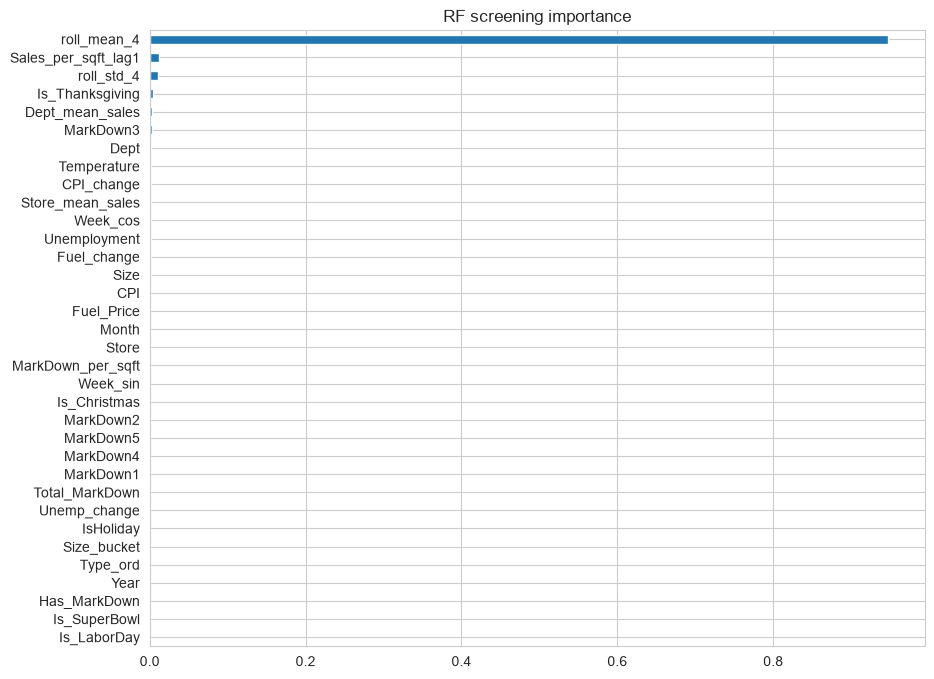

In [35]:
# Select your features wisely to avoid overfitting
TARGET = "Weekly_Sales"
CANDIDATES = ["Store","Dept","Size","Type_ord","IsHoliday","Is_SuperBowl","Is_LaborDay","Is_Thanksgiving","Is_Christmas",
              "Year","Month","WeekOfYear","Week_sin","Week_cos","Weeks_to_Christmas","Quarter",
              "Temperature","Fuel_Price","CPI","Unemployment","CPI_change","Fuel_change","Unemp_change",
              "MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5","Total_MarkDown","Has_MarkDown","MarkDown_Available","MarkDown_per_sqft",
              "lag_1","lag_2","lag_4","lag_8","lag_52","roll_mean_4","roll_mean_12","roll_std_4","Sales_per_sqft_lag1",
              "Store_mean_sales","Dept_mean_sales","Size_bucket"]

# (a) Drop near-constant features
var = df[CANDIDATES].var()
low_var = var[var < 1e-8].index.tolist()
# (b) Drop one of each highly-collinear pair (|r| > 0.95), keeping the one more correlated with target
c = df[CANDIDATES].corr().abs()
upper = c.where(np.triu(np.ones(c.shape), 1).astype(bool))
to_drop = set(low_var)
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.95 and row not in to_drop and col not in to_drop:
            weaker = row if abs(df[row].corr(df[TARGET])) < abs(df[col].corr(df[TARGET])) else col
            to_drop.add(weaker)
FEATURES = [f for f in CANDIDATES if f not in to_drop]
print("Dropped:", sorted(to_drop))
print(f"Selected {len(FEATURES)} features:", FEATURES)

# (c) Quick importance screen with a small Random Forest on a sample (final importances come from the tuned model in 7D)
sample = df.sample(min(60000, len(df)), random_state=RANDOM_STATE)
rf_screen = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE).fit(sample[FEATURES], sample[TARGET])
imp = pd.Series(rf_screen.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 8)); imp.plot.barh(); plt.gca().invert_yaxis(); plt.title("RF screening importance"); plt.show()

##### What all feature selection methods have you used and why?

1. **Variance threshold** — removes constant or near-constant variables that provide no predictive information.
2. **Correlation filter (|r| > 0.95)** — removes highly redundant variables to reduce multicollinearity and simplify interpretation.
3. **Tree-based importance screen** — a Random Forest screening model checks whether the retained variables provide useful predictive signal.

##### Which all features you found important and why?

In the executed final model, the strongest drivers are **`roll_mean_4`** and **`Sales_per_sqft_lag1`**, followed by holiday/seasonal and store-level signals such as **`Is_Thanksgiving`**, **`Size_bucket`**, **`Is_Christmas`**, **`Store_Cluster`**, **`Size`**, **`Store_mean_sales`** and **`Dept_mean_sales`**. These features capture recent demand, store scale, department/store baseline demand and major seasonal events.

The current correlation filter removed the raw `lag_1`, `lag_2`, `lag_4`, `lag_8` and `lag_52` columns because they were highly redundant with retained rolling/derived signals; this is why the naive lag benchmark is skipped later in the current executed run.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

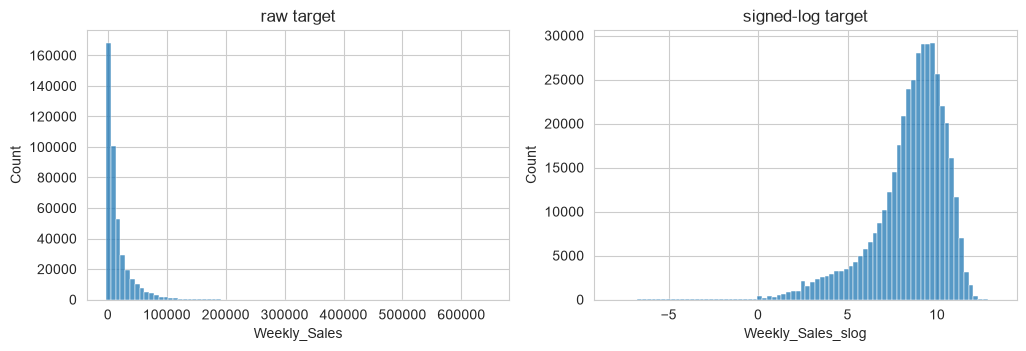

In [36]:
# Transform Your data
# The target is right-skewed with a long tail. For the *linear* model a log transform stabilises variance; tree models
# are invariant to monotone transforms so they use the raw target. Because negatives exist we use a signed log.
def signed_log1p(x):  return np.sign(x) * np.log1p(np.abs(x))
def signed_expm1(x):  return np.sign(x) * np.expm1(np.abs(x))
df["Weekly_Sales_slog"] = signed_log1p(df[TARGET])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(df[TARGET], bins=80, ax=ax[0]); ax[0].set_title("raw target")
sns.histplot(df["Weekly_Sales_slog"], bins=80, ax=ax[1]); ax[1].set_title("signed-log target")
plt.show()

Yes, partially. `Weekly_Sales` is strongly right-skewed and contains negatives, so a **signed log1p** transform is applied for the linear baseline (variance stabilisation, less leverage from huge weeks). Tree/boosting models are trained on the raw target because they are invariant to monotone transforms and because the business metric (WMAE) is computed in dollars.

### 6. Data Scaling

In [37]:
# Scaling your data
# Scaling is only required for distance/gradient-based methods: Linear/Ridge regression, K-Means, PCA, Isolation Forest (for stability).
# Trees do not need it. We fit the scaler on the TRAIN window only (defined in step 8) to avoid leakage;
# a helper is defined here and applied later.
scaler = StandardScaler()
def scale_fit_transform(train_X, test_X):
    Xs_tr = pd.DataFrame(scaler.fit_transform(train_X), columns=train_X.columns, index=train_X.index)
    Xs_te = pd.DataFrame(scaler.transform(test_X),      columns=test_X.columns, index=test_X.index)
    return Xs_tr, Xs_te
print("StandardScaler ready (fit on train only, applied in section 7).")

StandardScaler ready (fit on train only, applied in section 7).


##### Which method have you used to scale you data and why?

**StandardScaler (z-score)** — fitted on the training window only. It preserves outlier information (unlike MinMax which is dominated by a single extreme week) and puts CPI (~200), Size (~150,000) and Unemployment (~8) on a common scale for the linear model, K-Means and PCA.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Not for forecasting — ~40 features on 400K rows is small, and tree models handle it directly; reducing would only hurt interpretability. **PCA is used in the segmentation section** to (a) visualise the 45 stores in 2-D and (b) de-correlate the store-profile features before K-Means.

In [38]:
# DImensionality Reduction (If needed)
# Applied in section 7B (store segmentation). Placeholder here to keep template order.
print("PCA applied in Section 7B.")

PCA applied in Section 7B.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

PCA (2 components for visualisation; enough components to explain ≥90% variance for clustering) — see 7B. PCA is appropriate because the store-profile features are continuous, scaled and linearly correlated (size ↔ average sales).

### 8. Data Splitting

In [39]:
# Split your data to train and test. Choose Splitting ratio wisely.
# TIME-BASED split: last 12 weeks are the hold-out (a random split would leak future lags into training).
HOLDOUT_WEEKS = 12
cutoff = sorted(df.Date.unique())[-HOLDOUT_WEEKS]
train = df[df.Date <  cutoff].copy()
test  = df[df.Date >= cutoff].copy()
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
w_train = np.where(train.IsHoliday == 1, 5, 1)   # holiday weight used by the WMAE metric
w_test  = np.where(test.IsHoliday  == 1, 5, 1)
print(f"cutoff = {pd.Timestamp(cutoff).date()} | train {len(train):,} rows ({train.Date.nunique()} weeks) | test {len(test):,} rows ({test.Date.nunique()} weeks)")
print(f"train share = {len(train)/len(df):.1%}")

cutoff = 2012-08-10 | train 386,007 rows (131 weeks) | test 35,563 rows (12 weeks)
train share = 91.6%


##### What data splitting ratio have you used and why?

A **chronological split**: all weeks before the last 12 (~91% of rows) for training, the final 12 weeks (~9%) as the test set. Forecasting must be evaluated on *future* data — a random 80/20 split would place a store-dept's week *t* in test while *t−1* and *t+1* sit in train, letting lag features trivially leak the answer. Twelve weeks ≈ one quarter, the planning horizon the business actually uses, and it includes both ordinary and Labor-Day weeks.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

This is a regression problem, so class imbalance does not apply directly. Two related imbalances exist and are handled: (1) **holiday weeks are ~7% of rows** but matter most to the business → the evaluation metric weights them 5×, and the boosting models are trained with `sample_weight`; (2) **markdown data exists for only ~36% of weeks** → handled via the `MarkDown_Available` indicator rather than resampling.

In [40]:
# Handling Imbalanced Dataset (If needed)
print("Holiday-week share in train: {:.1%}".format((train.IsHoliday == 1).mean()))
print("Handled via sample_weight (5x on holidays) in model training + WMAE metric. No resampling required.")

Holiday-week share in train: 6.9%
Handled via sample_weight (5x on holidays) in model training + WMAE metric. No resampling required.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Sample weighting (5× for holiday rows) inside model fitting and in the evaluation metric — this mirrors how the business values holiday accuracy without distorting the time-series structure the way SMOTE-style resampling would.

## ***7. ML Model Implementation***

This section implements the four ML components of the brief:

* **7A – Anomaly Detection** (statistical, multivariate Isolation Forest, time-based residual analysis)
* **7B – Store Segmentation** (K-Means + hierarchical, evaluated with silhouette / Davies-Bouldin)
* **7C – Market Basket Analysis** (department co-movement + Apriori on inferred baskets)
* **7D – Demand Forecasting** — the three template "ML Models" (Linear/Ridge, Random Forest, Gradient Boosting) + SARIMA long-term view
* **7E – Impact of External Factors** on the forecast

### 7A. Anomaly Detection in Sales Data

#### A1. Statistical anomalies within each store-department (robust z-score & IQR)

In [41]:
# Statistical anomaly detection - relative to each store-dept's own history
grp = df.groupby(["Store","Dept"])["Weekly_Sales_raw"]
med = grp.transform("median")
mad = grp.transform(lambda s: (s - s.median()).abs().median()) + 1e-9
df["robust_z"] = 0.6745 * (df["Weekly_Sales_raw"] - med) / mad          # MAD-based z-score
q1, q3 = grp.transform(lambda s: s.quantile(.25)), grp.transform(lambda s: s.quantile(.75))
iqr = q3 - q1
df["anom_z"]   = (df["robust_z"].abs() > 3.5).astype(int)
df["anom_iqr"] = ((df["Weekly_Sales_raw"] < q1 - 3*iqr) | (df["Weekly_Sales_raw"] > q3 + 3*iqr)).astype(int)
df["anom_neg"] = (df["Weekly_Sales_raw"] < 0).astype(int)

print("Flagged by robust-z :", df.anom_z.sum(),   f"({df.anom_z.mean():.2%})")
print("Flagged by IQR      :", df.anom_iqr.sum(), f"({df.anom_iqr.mean():.2%})")
print("Negative sales      :", df.anom_neg.sum())

# What explains them? Cross-tab with holidays and markdown availability
stat_anom = df[df.anom_z == 1]
print("\nAnomalies by holiday:"); print(stat_anom.Holiday_Name.value_counts())
print("\nShare of anomalies in holiday weeks: {:.1%} (base rate {:.1%})".format(stat_anom.IsHoliday.mean(), df.IsHoliday.mean()))
print("Share with markdown running     : {:.1%} (base rate {:.1%})".format(stat_anom.Has_MarkDown.mean(), df.Has_MarkDown.mean()))

Flagged by robust-z : 16051 (3.81%)
Flagged by IQR      : 7173 (1.70%)
Negative sales      : 1285

Anomalies by holiday:
Holiday_Name
None            13610
Thanksgiving     1259
SuperBowl         496
Christmas         466
LaborDay          220
Name: count, dtype: int64

Share of anomalies in holiday weeks: 15.2% (base rate 7.0%)
Share with markdown running     : 40.8% (base rate 35.9%)


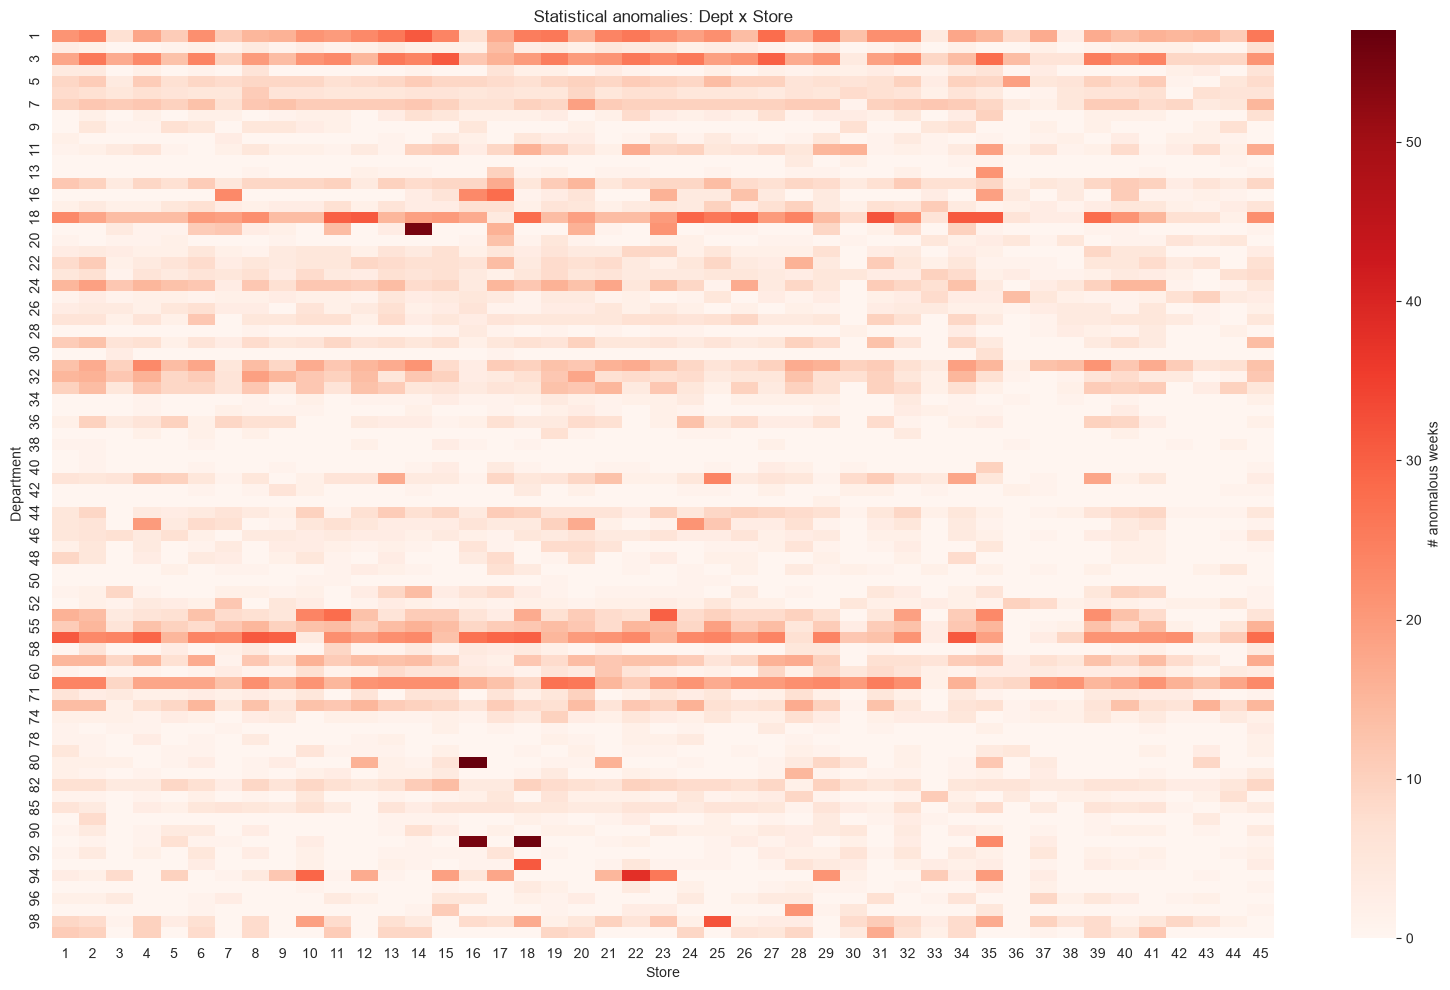

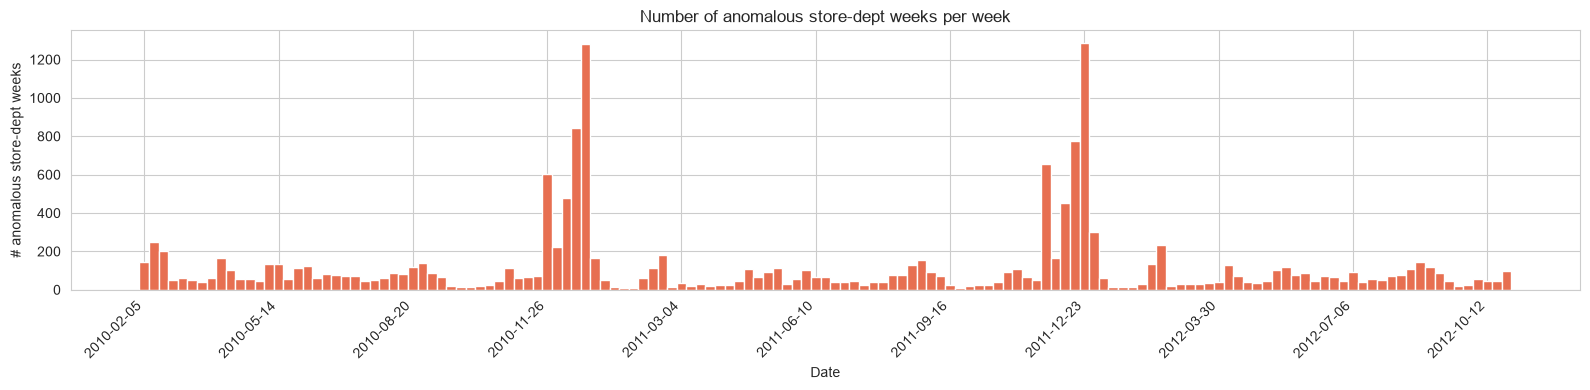

In [42]:
# Where are anomalies concentrated? Store x Dept heatmap of anomaly counts + timeline

# 1. Heatmap
pivot = stat_anom.pivot_table(
    index="Dept",
    columns="Store",
    values="anom_z",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot,
    cmap="Reds",
    cbar_kws={"label": "# anomalous weeks"}
)
plt.title("Statistical anomalies: Dept x Store")
plt.xlabel("Store")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


# 2. Timeline
timeline = (
    stat_anom
    .groupby("Date")
    .size()
    .sort_index()
)

x = np.arange(len(timeline))

plt.figure(figsize=(16, 4))
plt.bar(x, timeline.values, width=1, color="#e76f51")

# Show ~10 date labels
step = max(1, len(timeline) // 10)

plt.xticks(
    x[::step],
    [str(d)[:10] for d in timeline.index[::step]],
    rotation=45,
    ha="right"
)

plt.title("Number of anomalous store-dept weeks per week")
plt.xlabel("Date")
plt.ylabel("# anomalous store-dept weeks")
plt.tight_layout()
plt.show()

#### A2. Multivariate anomalies (Isolation Forest)

Isolation Forest flagged: 4216 (1.00%)
Overlap with robust-z flags: 398


,Store,Dept,Date,Weekly_Sales_raw,Holiday_Name,Total_MarkDown,CPI,Unemployment
127140,13,92,2012-02-03,176393.10,None,126999.28,130.349677,6.104
137310,14,92,2012-02-03,198551.21,None,143777.92,189.612228,8.424
19543,2,92,2012-02-03,176421.91,None,134773.51,219.811885,7.057
137739,14,95,2012-02-03,135853.14,None,143777.92,189.612228,8.424
127569,13,95,2012-02-03,135237.09,None,126999.28,130.349677,6.104
196735,20,92,2012-02-03,183393.93,None,129826.80,213.023622,6.961
38851,4,92,2012-02-03,178296.21,None,110681.95,130.349677,4.607
276155,28,92,2012-02-03,138487.57,None,104113.29,130.349677,12.187
19972,2,95,2012-02-03,136372.65,None,134773.51,219.811885,7.057
197164,20,95,2012-02-03,143446.23,None,129826.80,213.023622,6.961


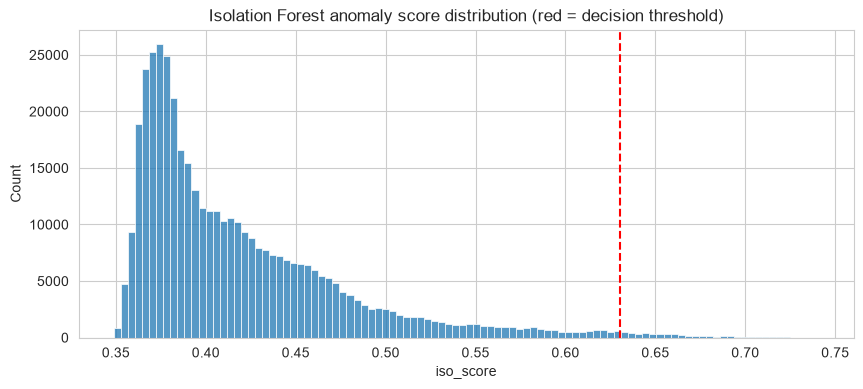

In [43]:
# Isolation Forest on the combination of sales, markdowns and economic context (unsupervised, no labels)
iso_feats = ["Weekly_Sales_raw","Total_MarkDown","MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5",
             "CPI","Unemployment","Fuel_Price","Temperature","IsHoliday","Size","Dept_mean_sales"]
iso_X = StandardScaler().fit_transform(df[iso_feats])
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1).fit(iso_X)
df["iso_score"] = -iso.score_samples(iso_X)          # higher = more anomalous
df["anom_iso"]  = (iso.predict(iso_X) == -1).astype(int)
print("Isolation Forest flagged:", df.anom_iso.sum(), f"({df.anom_iso.mean():.2%})")
print("Overlap with robust-z flags:", ((df.anom_iso == 1) & (df.anom_z == 1)).sum())
display(df.loc[df.anom_iso == 1].sort_values("iso_score", ascending=False)
          [["Store","Dept","Date","Weekly_Sales_raw","Holiday_Name","Total_MarkDown","CPI","Unemployment"]].head(15))
plt.figure(figsize=(10, 4)); sns.histplot(df.iso_score, bins=100); plt.axvline(df.loc[df.anom_iso==1, "iso_score"].min(), color="r", ls="--")
plt.title("Isolation Forest anomaly score distribution (red = decision threshold)"); plt.show()

#### A3. Time-based anomalies (residuals after trend + seasonality)

Store-level time anomalies: 79

Weeks flagged in most stores:
2010-04-02    18
2012-04-06    14
2010-02-05     5
2011-04-22     5
2011-04-08     3
2010-12-24     3
2011-12-23     3
2010-12-31     2
2011-12-30     2
2011-09-02     2
Name: count, dtype: int64


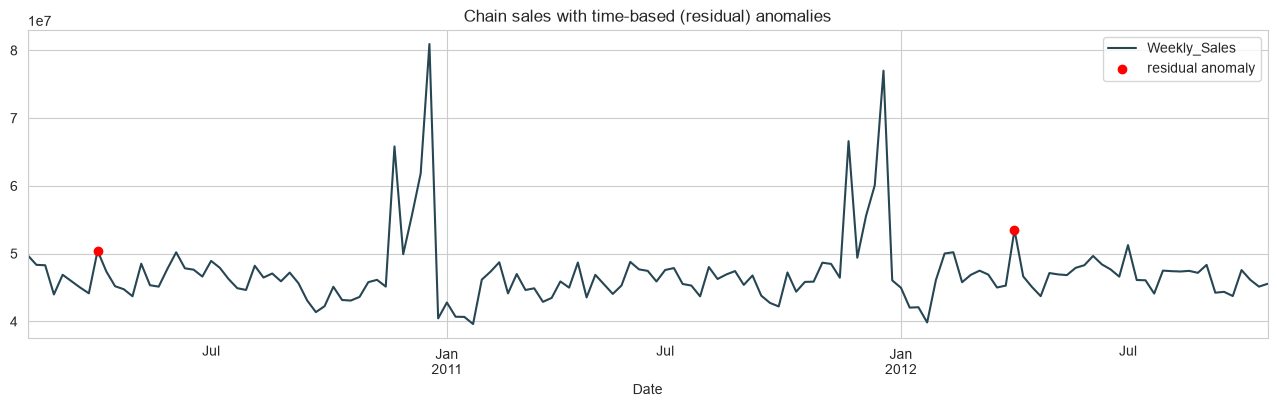

In [44]:
# Time-based anomaly detection: decompose per store (total store sales) and flag large residuals.
# Also done for the whole chain (ts) to catch chain-wide surprises.
def residual_anomalies(series, period=52, z=3.0):
    """Return boolean Series of residual-based anomalies for a weekly series."""
    if len(series) < 2*period:                      # decomposition needs >= 2 periods; fall back to rolling z
        r = series - series.rolling(8, center=True, min_periods=3).mean()
    else:
        r = seasonal_decompose(series, model="additive", period=period, extrapolate_trend="freq").resid
    rz = (r - r.mean()) / (r.std() + 1e-9)
    return rz.abs() > z, rz

store_ts = df.groupby(["Store","Date"])["Weekly_Sales_raw"].sum().unstack(0)
time_anoms = {}
for s in store_ts.columns:
    flag, rz = residual_anomalies(store_ts[s].dropna())
    time_anoms[s] = flag[flag].index.tolist()
n_time = sum(len(v) for v in time_anoms.values())
print("Store-level time anomalies:", n_time)
# Which weeks are anomalous for the most stores?
week_counts = pd.Series([d for v in time_anoms.values() for d in v]).value_counts().head(10)
print("\nWeeks flagged in most stores:"); print(week_counts)

# Chain-level view with anomalies marked
flag_c, rz_c = residual_anomalies(ts)
plt.figure(figsize=(16, 4)); ts.plot(color="#264653"); plt.scatter(ts.index[flag_c], ts[flag_c], color="red", zorder=5, label="residual anomaly")
plt.legend(); plt.title("Chain sales with time-based (residual) anomalies"); plt.show()

#### A4. Anomaly handling strategy

anom_reason
unexplained             8168
markdown-driven         7288
holiday:Thanksgiving    1875
holiday:Christmas       1392
holiday:SuperBowl        834
holiday:LaborDay         233
net-returns               79
Name: count, dtype: int64


,count,mean,min,max
anom_reason,,,,
holiday:Christmas,1392,24112.571767,-798.00,156431.46
holiday:LaborDay,233,29342.584163,-598.00,182296.84
holiday:SuperBowl,834,33353.872602,-500.00,233140.32
holiday:Thanksgiving,1875,41758.491136,-169.98,693099.36
markdown-driven,7288,27512.040542,-1699.00,341308.00
net-returns,79,-413.216456,-4988.94,-2.50
normal,401701,15413.497362,-771.90,244628.76
unexplained,8168,24315.714177,0.00,406988.63


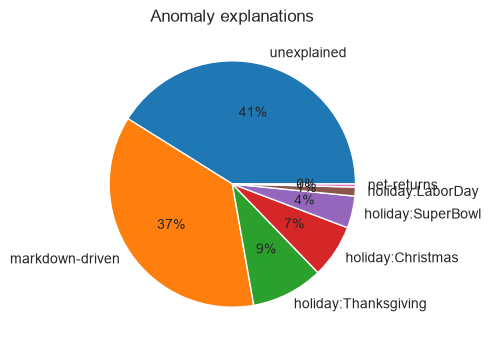

In [45]:
# Consolidate flags -> a single anomaly label and an explanation column, then decide treatment.
df["anom_any"] = ((df.anom_z + df.anom_iso) > 0).astype(int)
def explain(row):
    if row.Holiday_Name != "None":      return f"holiday:{row.Holiday_Name}"
    if row.Has_MarkDown:                return "markdown-driven"
    if row.Weekly_Sales_raw < 0:        return "net-returns"
    return "unexplained"
df["anom_reason"] = "normal"
df.loc[df.anom_any == 1, "anom_reason"] = df[df.anom_any == 1].apply(explain, axis=1)
print(df.loc[df.anom_any == 1, "anom_reason"].value_counts())

# Treatment (already applied in section 6.2 as per-series winsorisation):
#  - explained anomalies (holiday / markdown) are KEPT -> the forecaster must learn them
#  - unexplained extremes are capped at the series' 99.5th percentile -> Weekly_Sales
#  - all flags are retained as features/diagnostics, never deleted
anom_summary = df.groupby("anom_reason")["Weekly_Sales_raw"].agg(["count","mean","min","max"])
display(anom_summary)
plt.figure(figsize=(8, 4)); df.loc[df.anom_any==1, "anom_reason"].value_counts().plot.pie(autopct="%1.0f%%"); plt.ylabel(""); plt.title("Anomaly explanations"); plt.show()

##### Anomaly detection — model explanation & business interpretation

* **Robust statistical layer:** 16,051 rows (**3.81%**) are flagged by robust z-score and 7,173 (**1.70%**) by the wider IQR rule. Holiday weeks represent **15.2% of robust-z anomalies** although they are only **7.0% of observations**, showing that genuine retail events are an important source of extreme sales.
* **Isolation Forest:** 4,216 rows (**1.00%**) are flagged using the combined sales, markdown and economic context. Only **398 rows** overlap with robust-z anomalies, indicating that the methods detect different kinds of unusual behaviour.
* **Time-series residual layer:** 79 store-level time anomalies are identified; common multi-store dates include 2010-04-02 and 2012-04-06, which are useful candidates for event/calendar investigation.
* **Consolidated interpretation:** 19,869 rows (**4.71%**) are classified as anomalies. The largest explanation groups are `unexplained` (8,168) and `markdown-driven` (7,288), followed by Thanksgiving (1,875), Christmas (1,392), Super Bowl (834), Labor Day (233) and net returns (79).
* **Business treatment:** rows are not blindly deleted. Known holiday/promotion events are retained so the forecasting model can learn them, while extreme values are winsorised at the Store-Department level for modelling stability.

### 7B. Store Segmentation (Customer Segmentation Analysis)

#### B1. Build store-level profile

In [46]:
# Store profile: sales level, volatility, seasonality response, markdown behaviour, regional economics, size
post_md = df[df.MarkDown_Available == 1]
profile = df.groupby("Store").agg(
    avg_weekly_sales = ("Weekly_Sales", "mean"),
    sales_cv         = ("Weekly_Sales", lambda s: s.std() / (s.mean() + 1e-9)),
    n_depts          = ("Dept", "nunique"),
    Size             = ("Size", "first"),
    Type_ord         = ("Type_ord", "first"),
    avg_CPI          = ("CPI", "mean"),
    avg_unemp        = ("Unemployment", "mean"),
    avg_fuel         = ("Fuel_Price", "mean"),
    avg_temp         = ("Temperature", "mean"),
    anomaly_rate     = ("anom_any", "mean"),
)
# holiday uplift = holiday mean / non-holiday mean
hol_up = df.groupby(["Store","IsHoliday"])["Weekly_Sales"].mean().unstack()
profile["holiday_uplift"] = hol_up[1] / hol_up[0]
# markdown intensity relative to sales (post Nov-2011)
mdint = post_md.groupby("Store").apply(lambda g: g.Total_MarkDown.sum() / (g.Weekly_Sales.sum() + 1e-9))
profile["markdown_intensity"] = mdint
# sales growth: last 52 weeks vs previous 52
last = df.Date.max()
g_recent = df[df.Date > last - pd.Timedelta(weeks=52)].groupby("Store").Weekly_Sales.sum()
g_prev   = df[(df.Date <= last - pd.Timedelta(weeks=52)) & (df.Date > last - pd.Timedelta(weeks=104))].groupby("Store").Weekly_Sales.sum()
profile["yoy_growth"] = g_recent / g_prev - 1
profile["sales_per_sqft"] = profile.avg_weekly_sales / profile.Size
profile = profile.fillna(profile.median())
display(profile.round(3).head(10))

,avg_weekly_sales,sales_cv,n_depts,Size,Type_ord,avg_CPI,avg_unemp,avg_fuel,avg_temp,anomaly_rate,holiday_uplift,markdown_intensity,yoy_growth,sales_per_sqft
Store,,,,,,,,,,,,,,
1,21698.744,1.277,77,151315,3,215.996,7.611,3.219,68.224,0.046,1.067,0.912,0.047,0.143
2,26877.046,1.228,78,202307,3,215.652,7.623,3.220,68.105,0.062,1.077,1.031,0.027,0.133
3,6369.506,2.237,72,37392,2,219.403,7.176,3.219,71.299,0.027,1.091,1.021,0.073,0.170
4,29145.153,1.185,78,205863,3,128.680,5.966,3.216,62.177,0.062,1.063,0.880,0.055,0.142
5,5050.276,1.597,72,34875,2,216.577,6.297,3.221,69.204,0.034,1.118,1.529,0.079,0.145
6,21898.106,1.077,77,202505,3,217.565,6.606,3.221,69.640,0.050,1.069,1.038,0.033,0.108
7,8348.423,1.271,76,70713,2,193.672,8.585,3.240,39.603,0.031,1.173,1.553,0.054,0.118
8,13124.655,1.151,76,155078,3,219.438,6.092,3.219,62.447,0.041,1.073,1.318,0.025,0.085
9,8766.884,1.417,73,125833,2,219.684,6.096,3.224,67.647,0.034,1.077,1.059,0.058,0.070


#### B2. Choose k (elbow + silhouette) and fit K-Means

PCA components for 90% variance: 6 | explained: [0.411 0.164 0.133 0.102 0.067 0.06 ]


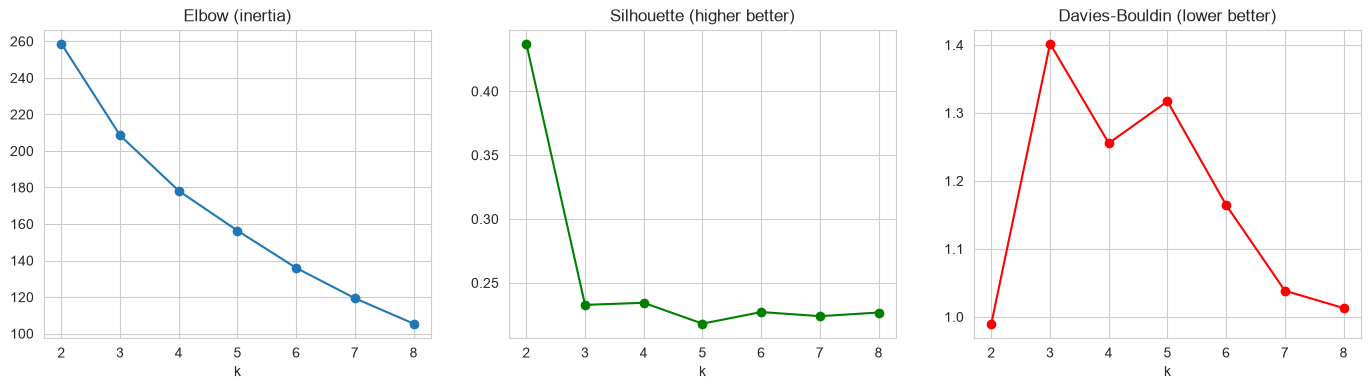

Best k by silhouette: 2 | silhouette = 0.437


In [47]:
# Scale + PCA + K-Means with k selection
seg_feats = ["avg_weekly_sales","sales_cv","Size","holiday_uplift","markdown_intensity","avg_CPI","avg_unemp","yoy_growth","sales_per_sqft","anomaly_rate"]
Xseg = StandardScaler().fit_transform(profile[seg_feats])

pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit(Xseg)
Xpca = pca.transform(Xseg)
print(f"PCA components for 90% variance: {pca.n_components_} | explained: {pca.explained_variance_ratio_.round(3)}")

ks = range(2, 9)
inertia, sil, dbi = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xpca)
    inertia.append(km.inertia_); sil.append(silhouette_score(Xpca, km.labels_)); dbi.append(davies_bouldin_score(Xpca, km.labels_))
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(ks, sil, "o-", color="g"); ax[1].set_title("Silhouette (higher better)")
ax[2].plot(ks, dbi, "o-", color="r"); ax[2].set_title("Davies-Bouldin (lower better)")
for a in ax: a.set_xlabel("k")
plt.show()
best_k = ks[int(np.argmax(sil))]
print("Best k by silhouette:", best_k, "| silhouette =", round(max(sil), 3))

Silhouette  KM = 0.437 | HC = 0.422
Davies-Bouldin KM = 0.990 | HC = 0.994
Calinski-Harabasz KM = 27.1

Agreement KM vs HC (crosstab):


cluster_hc,0,1
cluster_km,,
0,36,0
1,1,8


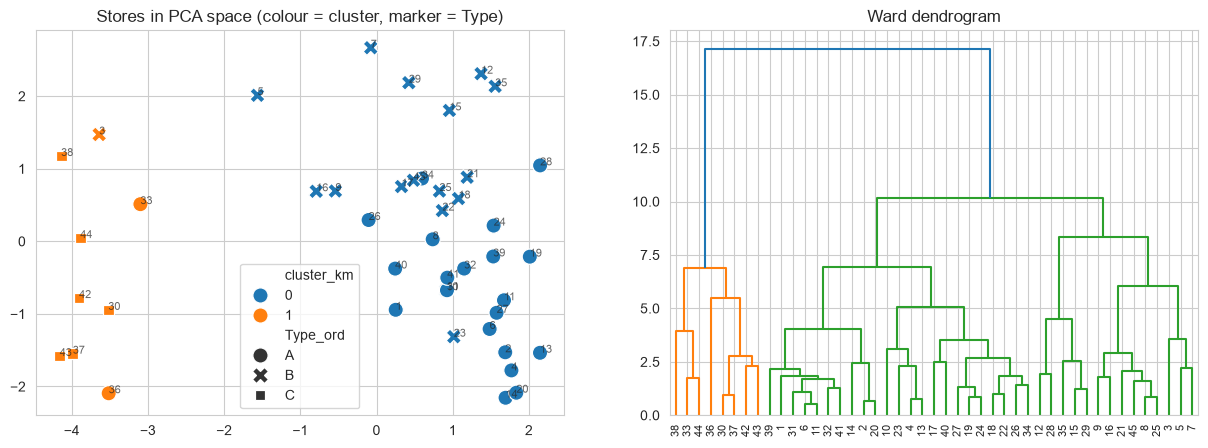

In [48]:
# Fit final K-Means and hierarchical cross-check
K = best_k            # <-- override manually if business logic prefers a different k
kmeans = KMeans(n_clusters=K, n_init=50, random_state=RANDOM_STATE).fit(Xpca)
profile["cluster_km"] = kmeans.labels_
agg = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(Xpca)
profile["cluster_hc"] = agg.labels_

print("Silhouette  KM = {:.3f} | HC = {:.3f}".format(silhouette_score(Xpca, kmeans.labels_), silhouette_score(Xpca, agg.labels_)))
print("Davies-Bouldin KM = {:.3f} | HC = {:.3f}".format(davies_bouldin_score(Xpca, kmeans.labels_), davies_bouldin_score(Xpca, agg.labels_)))
print("Calinski-Harabasz KM = {:.1f}".format(calinski_harabasz_score(Xpca, kmeans.labels_)))
print("\nAgreement KM vs HC (crosstab):"); display(pd.crosstab(profile.cluster_km, profile.cluster_hc))

# 2-D visualisation
p2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xseg)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=p2[:,0], y=p2[:,1], hue=profile.cluster_km.astype(str), style=profile.Type_ord.map({3:"A",2:"B",1:"C"}), s=120, ax=ax[0])
for i, s in enumerate(profile.index): ax[0].annotate(s, (p2[i,0], p2[i,1]), fontsize=8, alpha=.7)
ax[0].set_title("Stores in PCA space (colour = cluster, marker = Type)")
# dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
dendrogram(linkage(Xpca, "ward"), labels=profile.index.tolist(), ax=ax[1]); ax[1].set_title("Ward dendrogram")
plt.show()

#### B3. Interpret segments & evaluate quality

,avg_weekly_sales,sales_cv,Size,holiday_uplift,markdown_intensity,avg_CPI,avg_unemp,yoy_growth,sales_per_sqft,anomaly_rate,Type_ord,n_stores,stores
cluster_km,,,,,,,,,,,,,
0,17114.090,1.238,152852.778,1.081,1.292,170.400,7.853,0.026,0.114,0.051,2.556,36,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1..."
1,8678.953,1.682,40026.889,1.009,0.325,176.378,8.564,0.034,0.216,0.025,1.556,9,"[3, 30, 33, 36, 37, 38, 42, 43, 44]"


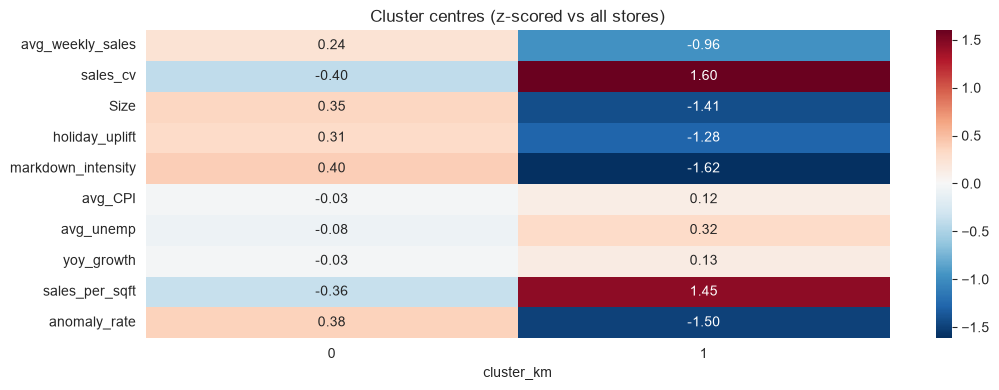

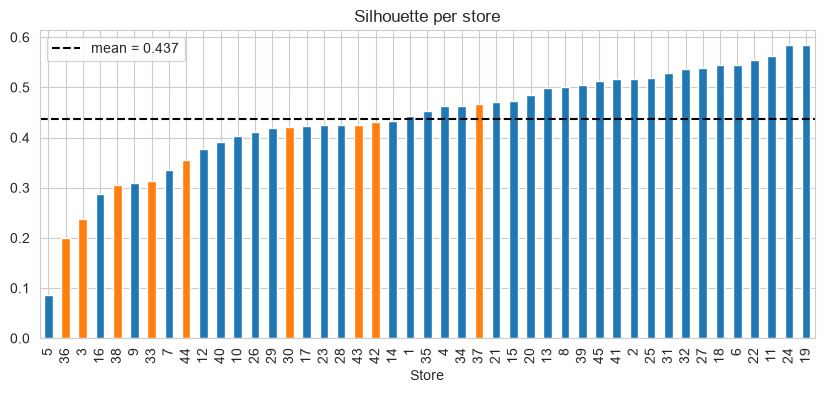

In [49]:
# Segment profile table + silhouette plot per sample
seg_table = profile.groupby("cluster_km")[seg_feats + ["Type_ord"]].mean().round(3)
seg_table["n_stores"] = profile.cluster_km.value_counts().sort_index()
seg_table["stores"] = profile.groupby("cluster_km").apply(lambda g: list(g.index))
display(seg_table)

# Normalised heatmap of cluster centres for interpretation
plt.figure(figsize=(12, 4))
sns.heatmap(((seg_table[seg_feats] - profile[seg_feats].mean()) / profile[seg_feats].std()).T, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Cluster centres (z-scored vs all stores)"); plt.show()

# Per-store silhouette values
from sklearn.metrics import silhouette_samples
sv = silhouette_samples(Xpca, kmeans.labels_)
plt.figure(figsize=(10, 4)); pd.Series(sv, index=profile.index).sort_values().plot.bar(color=[plt.cm.tab10(c) for c in profile.cluster_km.loc[pd.Series(sv, index=profile.index).sort_values().index]])
plt.axhline(sv.mean(), color="k", ls="--", label=f"mean = {sv.mean():.3f}"); plt.legend(); plt.title("Silhouette per store"); plt.show()

# Attach cluster back to main frame for later use (forecasting feature + strategy)
df = df.drop(columns=["Store_Cluster"], errors="ignore").merge(profile[["cluster_km"]].rename(columns={"cluster_km":"Store_Cluster"}), left_on="Store", right_index=True, how="left")
train["Store_Cluster"] = train.Store.map(profile.cluster_km); test["Store_Cluster"] = test.Store.map(profile.cluster_km)

##### Segmentation — methodology, interpretation & quality

* **Unit of segmentation:** stores, because customer-level identifiers are not available.
* **Method:** 10 store-profile variables → StandardScaler → PCA retaining at least 90% variance → K-Means. Ward hierarchical clustering is used as a robustness check.
* **PCA:** 6 components retain the required 90%+ variance.
* **Selected K:** **2**, chosen by the highest silhouette score.
* **Quality:** K-Means silhouette = **0.437**, Davies-Bouldin = **0.990**, Calinski-Harabasz = **27.1**. Hierarchical clustering gives silhouette = 0.422 and DBI = 0.994. The methods agree strongly: 36 K-Means Cluster-0 stores map to one HC group, and 8 of 9 Cluster-1 stores map to the other.
* **Cluster 0 — Large / higher-volume / promotion-active stores:** 36 stores; average weekly sales ≈ **17,114**, average size ≈ **152,853 sq ft**, holiday uplift ≈ **1.081**, markdown intensity ≈ **1.292**, anomaly rate ≈ **5.1%**.
* **Cluster 1 — Small / lower-volume but higher sales-efficiency stores:** 9 stores; average weekly sales ≈ **8,679**, average size ≈ **40,027 sq ft**, sales per sq ft ≈ **0.216** versus 0.114 in Cluster 0, and anomaly rate ≈ **2.5%**.
* These clusters add behaviour/economic context beyond the original A/B/C store labels and support differentiated stocking and promotion policies.

### 7C. Market Basket Analysis (inferred from department co-movement)

*No transaction data exists, so 'items' = departments and a 'basket' = a store-week. Two complementary inferences: (1) correlation of week-over-week sales changes between departments; (2) Apriori on binarised 'department had an above-median week' baskets.*

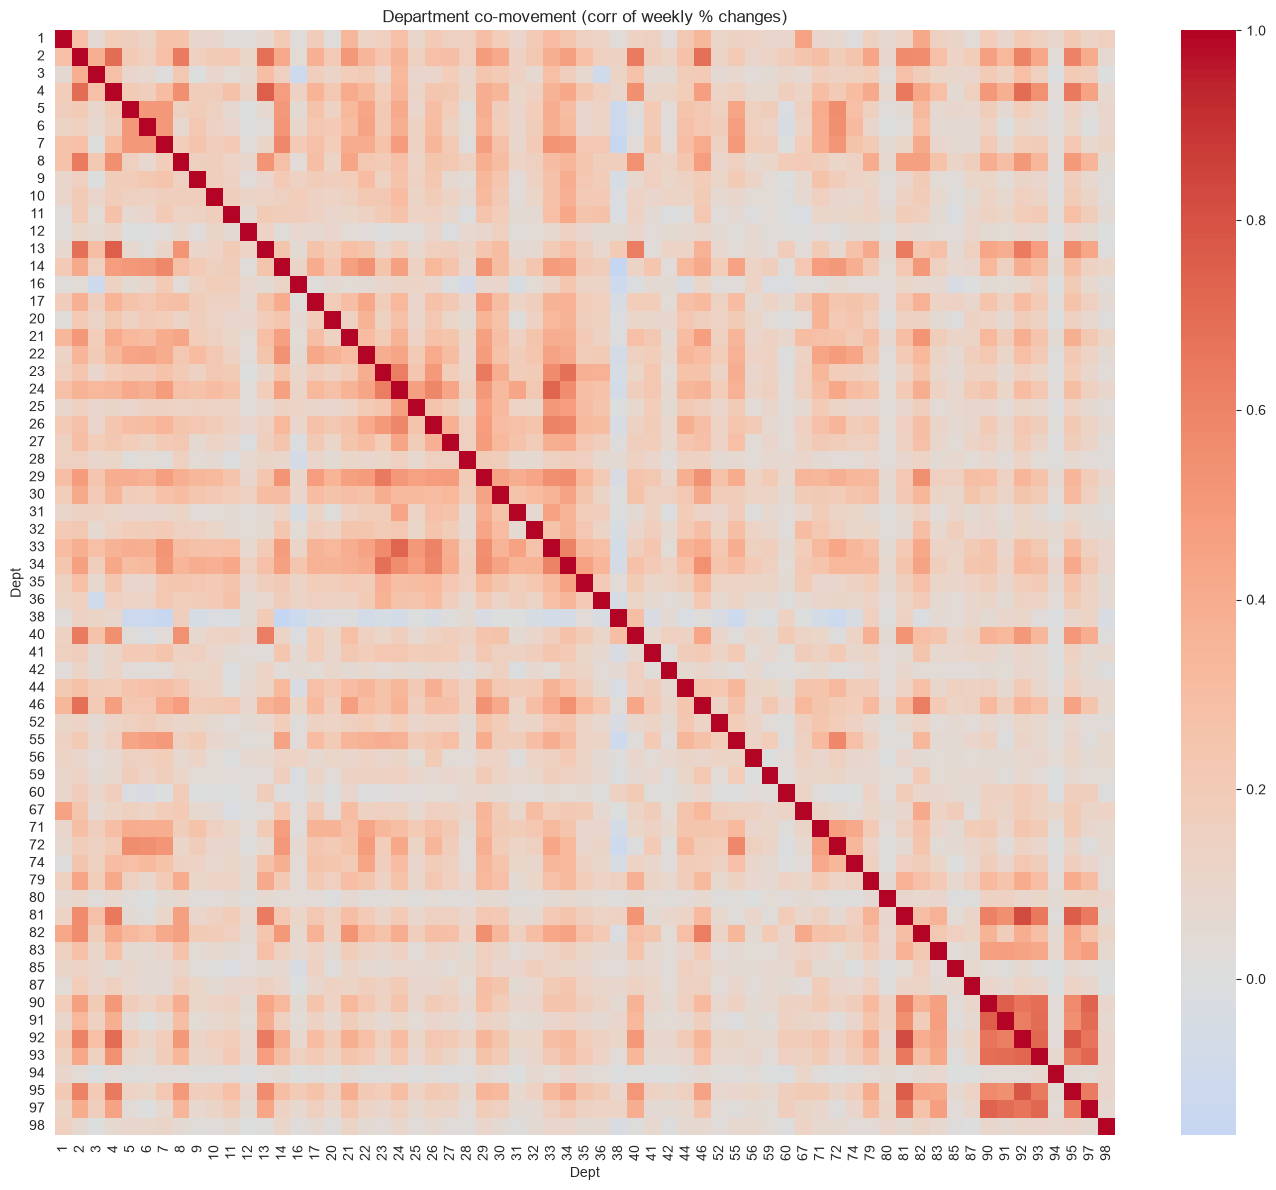

Top 15 co-moving department pairs:


,Dept_A,Dept_B,corr
0,81,92,0.820077
1,92,95,0.785005
2,81,95,0.759476
3,4,13,0.752459
4,90,91,0.751017
5,90,97,0.739307
6,24,33,0.728526
7,92,93,0.724590
8,93,97,0.722070
9,91,97,0.703654



Most negatively related (substitutes / cannibalisation candidates):


,Dept_A,Dept_B,corr
1952,14,38,-0.164752
1951,7,38,-0.155478
1950,6,38,-0.127620
1949,5,38,-0.120228
1948,38,55,-0.114571
1947,16,38,-0.112830
1946,3,16,-0.110242
1945,38,72,-0.107190


In [50]:
# C1. Department co-movement: correlation of de-seasonalised weekly changes

dept_wk = df.pivot_table(
    index=["Store", "Date"],
    columns="Dept",
    values="Weekly_Sales",
    aggfunc="sum"
)

# Keep departments present in >80% of store-weeks
dept_wk = dept_wk.loc[:, dept_wk.notna().mean() > 0.8]

# Week-over-week % change within each store
chg = (
    dept_wk
    .groupby(level=0)
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

chg = chg.clip(-5, 5)

# Department correlation
dept_corr = chg.corr(min_periods=500)

plt.figure(figsize=(14, 12))
sns.heatmap(
    dept_corr,
    cmap="coolwarm",
    center=0,
    xticklabels=True,
    yticklabels=True
)
plt.title("Department co-movement (corr of weekly % changes)")
plt.tight_layout()
plt.show()


# Get unique department pairs only
upper_mask = np.triu(
    np.ones(dept_corr.shape, dtype=bool),
    k=1
)

pairs = (
    dept_corr
    .where(upper_mask)
    .stack()
    .sort_values(ascending=False)
)

# FIX: explicitly name the two MultiIndex levels
pairs.index = pairs.index.set_names(["Dept_A", "Dept_B"])

# Convert once to a clean dataframe
pairs_df = (
    pairs
    .rename("corr")
    .reset_index()
)


print("Top 15 co-moving department pairs:")
display(pairs_df.head(15))


print("\nMost negatively related (substitutes / cannibalisation candidates):")
display(
    pairs_df
    .sort_values("corr")
    .head(8)
)

13387 frequent itemsets | 74196 rules


,antecedents,consequents,support,confidence,lift
61157,frozenset({D33}),"frozenset({D34, D24})",0.340948,0.814100,2.307813
61152,"frozenset({D34, D24})",frozenset({D33}),0.340948,0.966520,2.307813
66434,"frozenset({D30, D33})",frozenset({D34}),0.329759,0.953279,2.303550
66435,frozenset({D34}),"frozenset({D30, D33})",0.329759,0.796846,2.303550
61206,"frozenset({D71, D24})",frozenset({D33}),0.321212,0.964086,2.302001
61211,frozenset({D33}),"frozenset({D71, D24})",0.321212,0.766976,2.302001
60962,"frozenset({D30, D24})",frozenset({D34}),0.326651,0.951993,2.300441
60963,frozenset({D34}),"frozenset({D30, D24})",0.326651,0.789335,2.300441
27035,frozenset({D33}),"frozenset({D6, D24})",0.307226,0.733581,2.299363
27030,"frozenset({D6, D24})",frozenset({D33}),0.307226,0.962981,2.299363


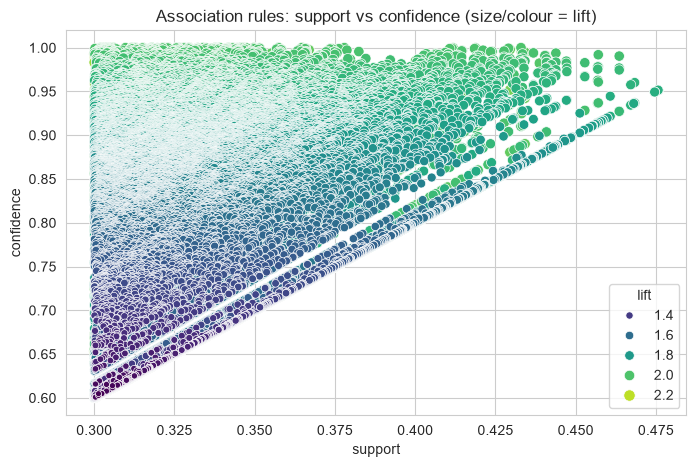

In [51]:
# C2. Apriori on inferred baskets: item present if the department's sales that store-week exceed its own median
if mlxtend is not None:
    from mlxtend.frequent_patterns import apriori, association_rules
    basket = (dept_wk > dept_wk.median()).astype(bool)
    basket.columns = [f"D{c}" for c in basket.columns]
    freq = apriori(basket, min_support=0.30, use_colnames=True, max_len=3)
    rules = association_rules(freq, metric="lift", min_threshold=1.2)
    rules = rules.sort_values("lift", ascending=False)
    print(f"{len(freq)} frequent itemsets | {len(rules)} rules")
    display(rules[["antecedents","consequents","support","confidence","lift"]].head(20))
    plt.figure(figsize=(8, 5)); sns.scatterplot(data=rules, x="support", y="confidence", size="lift", hue="lift", palette="viridis")
    plt.title("Association rules: support vs confidence (size/colour = lift)"); plt.show()
else:
    print("mlxtend not available - Apriori skipped; correlation-based associations above stand alone.")

In [52]:
# C3. Cross-selling candidates: high-lift pairs where one dept is large (anchor) and the other smaller (attach)
dept_size = df.groupby("Dept").Weekly_Sales.mean()
top_pairs = pairs.head(30).reset_index().rename(columns={"level_0":"Dept_A","level_1":"Dept_B", 0:"corr"})
top_pairs["size_A"] = top_pairs.Dept_A.map(dept_size).round(0); top_pairs["size_B"] = top_pairs.Dept_B.map(dept_size).round(0)
top_pairs["anchor"] = np.where(top_pairs.size_A >= top_pairs.size_B, top_pairs.Dept_A, top_pairs.Dept_B)
top_pairs["attach"] = np.where(top_pairs.size_A >= top_pairs.size_B, top_pairs.Dept_B, top_pairs.Dept_A)
display(top_pairs[["anchor","attach","corr","size_A","size_B"]].head(15))

,anchor,attach,corr,size_A,size_B
0,92,81,0.820077,15469.0,75187.0
1,92,95,0.785005,75187.0,69816.0
2,95,81,0.759476,15469.0,69816.0
3,13,4,0.752459,25973.0,30664.0
4,90,91,0.751017,45222.0,33681.0
5,90,97,0.739307,45222.0,14253.0
6,33,24,0.728526,6349.0,6467.0
7,92,93,0.724590,75187.0,27000.0
8,93,97,0.722070,27000.0,14253.0
9,91,97,0.703654,33681.0,14253.0


##### Market basket — insights & cross-selling strategy

* The strongest department co-movement is **Dept 81–92 (corr ≈ 0.820)**, followed by **92–95 (0.785)** and **81–95 (0.759)**. These are candidates for adjacent placement, bundle testing or coordinated promotions.
* The strongest negative pair in the current analysis is **Dept 14–38 (corr ≈ -0.165)**. Negative relationships can be treated as possible substitution/cannibalisation signals and should be validated before running simultaneous promotions.
* Apriori produces **13,387 frequent itemsets** and **74,196 association rules** at the chosen thresholds. The highest displayed lift is about **2.31**, indicating that some above-median department combinations occur together substantially more often than expected under independence.
* These are **co-movement / inferred basket** relationships, not literal customer co-purchases, because transaction-level basket IDs are not available. Recommendations therefore require merchandising validation before deployment.

### 7D. Demand Forecasting

#### Evaluation helpers

In [53]:
# Metrics: WMAE (holiday-weighted MAE, the original competition metric), MAE, RMSE, R2
def wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def evaluate(name, y_true, y_pred, weights, store=None):
    res = dict(model=name,
               WMAE=wmae(y_true, y_pred, weights),
               MAE=mean_absolute_error(y_true, y_pred),
               RMSE=math.sqrt(mean_squared_error(y_true, y_pred)),
               R2=r2_score(y_true, y_pred))
    if store is not None: store.append(res)
    print(f"{name:32s} WMAE={res['WMAE']:>10,.0f}  MAE={res['MAE']:>10,.0f}  RMSE={res['RMSE']:>10,.0f}  R2={res['R2']:.4f}")
    return res

def score_chart(results, title="Model comparison"):
    r = pd.DataFrame(results).set_index("model")
    fig, ax = plt.subplots(1, 4, figsize=(20, 4))
    for i, m in enumerate(["WMAE","MAE","RMSE","R2"]):
        r[m].plot.bar(ax=ax[i], color="#2a9d8f"); ax[i].set_title(m); ax[i].tick_params(axis="x", rotation=30)
    plt.suptitle(title); plt.tight_layout(); plt.show()
    return r

RESULTS = []
# add cluster as a feature now that it exists
if "Store_Cluster" not in FEATURES: FEATURES = FEATURES + ["Store_Cluster"]
X_train, X_test = train[FEATURES], test[FEATURES]

### ML Model - 1 : Linear / Ridge Regression (baseline)

In [54]:
# ML Model - 1 Implementation

Xs_tr, Xs_te = scale_fit_transform(X_train, X_test)
y_tr_log = signed_log1p(y_train)

# Linear Regression
lin = LinearRegression().fit(
    Xs_tr,
    y_tr_log,
    sample_weight=w_train
)

pred_lin = signed_expm1(lin.predict(Xs_te))

evaluate(
    "Linear Regression (log target)",
    y_test,
    pred_lin,
    w_test,
    RESULTS
)


# --------------------------------------------------
# Naive benchmarks
# --------------------------------------------------

if "lag_1" in X_test.columns:
    evaluate(
        "Naive: last week (lag_1)",
        y_test,
        X_test["lag_1"],
        w_test,
        RESULTS
    )
else:
    print("Skipping lag_1 benchmark: 'lag_1' not present in X_test")


if "lag_52" in X_test.columns:
    evaluate(
        "Naive: same week last year (lag_52)",
        y_test,
        X_test["lag_52"],
        w_test,
        RESULTS
    )
else:
    print("Skipping lag_52 benchmark: 'lag_52' not present in X_test")

Linear Regression (log target)   WMAE=    32,342  MAE=    34,164  RMSE=   388,725  R2=-314.1276
Skipping lag_1 benchmark: 'lag_1' not present in X_test
Skipping lag_52 benchmark: 'lag_52' not present in X_test


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

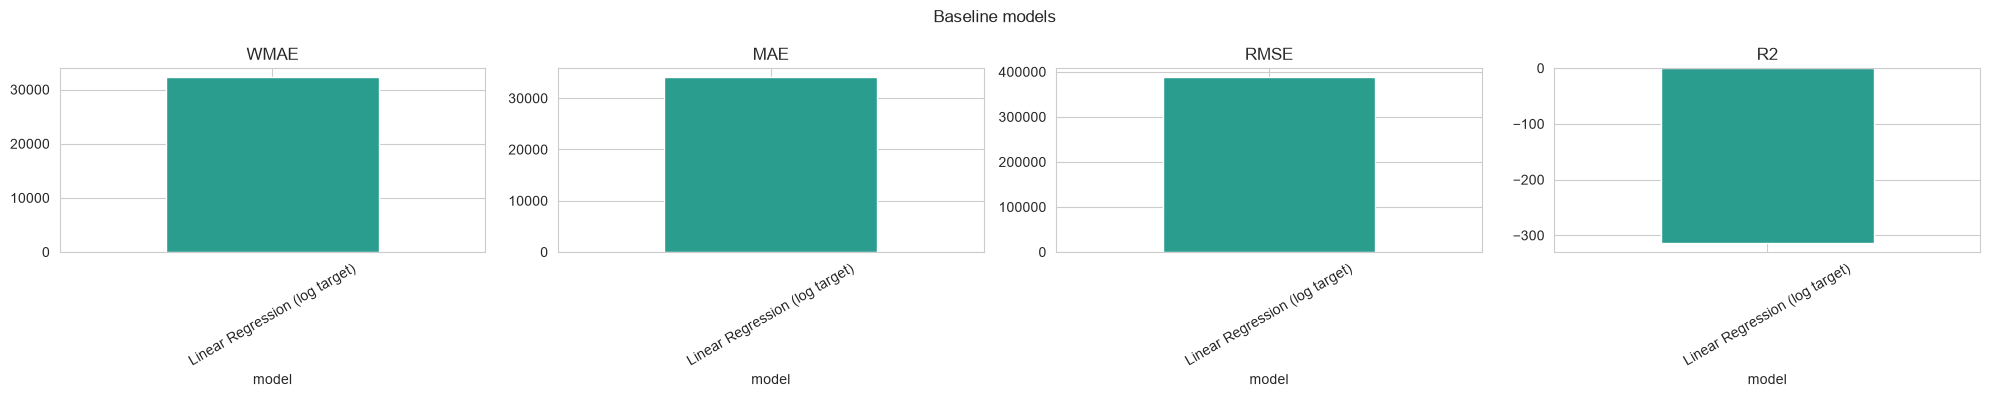

In [55]:
# Visualizing evaluation Metric Score chart
_ = score_chart(RESULTS, "Baseline models")

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (GridSearch / RandomSearch with TimeSeriesSplit)
tscv = TimeSeriesSplit(n_splits=4)
ridge_search = RandomizedSearchCV(Ridge(), {"alpha": np.logspace(-3, 3, 25)}, n_iter=12, cv=tscv,
                                  scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1)
ridge_search.fit(Xs_tr, y_tr_log, sample_weight=w_train)
print("Best alpha:", ridge_search.best_params_, "| CV MAE (log space):", -ridge_search.best_score_.round(4))
pred_ridge = signed_expm1(ridge_search.best_estimator_.predict(Xs_te))
evaluate("Ridge (tuned, TimeSeriesCV)", y_test, pred_ridge, w_test, RESULTS)

Best alpha: {'alpha': np.float64(0.001)} | CV MAE (log space): 1.0302
Ridge (tuned, TimeSeriesCV)      WMAE=    32,342  MAE=    34,164  RMSE=   388,725  R2=-314.1275


{'model': 'Ridge (tuned, TimeSeriesCV)',
 'WMAE': np.float64(32342.36480792246),
 'MAE': 34163.66845374303,
 'RMSE': 388724.8447427908,
 'R2': -314.12754459049114}

##### Which hyperparameter optimization technique have you used and why?

`RandomizedSearchCV` is used over the Ridge `alpha` parameter with **TimeSeriesSplit (4 folds)**. Chronological validation keeps every validation period after its corresponding training period and is therefore more appropriate than random CV for forecasting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No material improvement is observed. Linear Regression gives **WMAE ≈ 32,342**, and tuned Ridge also gives **WMAE ≈ 32,342** with virtually identical MAE/RMSE/R². This confirms that regularisation alone cannot capture the strong nonlinear Store × Department × seasonal interactions in this problem.

### ML Model - 2 : Random Forest Regressor

In [57]:
# ML Model - 2 Implementation
# Fit the Algorithm (subsample rows for speed if needed; set SUBSAMPLE=None to use all rows)
SUBSAMPLE = 150_000
idx = train.sample(SUBSAMPLE, random_state=RANDOM_STATE).index if SUBSAMPLE and SUBSAMPLE < len(train) else train.index
rf = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=3, max_features=0.5, n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time(); rf.fit(X_train.loc[idx], y_train.loc[idx], sample_weight=w_train[train.index.get_indexer(idx)])
print(f"fit time {time.time()-t0:.0f}s")
# Predict on the model
pred_rf = rf.predict(X_test)
evaluate("Random Forest", y_test, pred_rf, w_test, RESULTS)

fit time 48s
Random Forest                    WMAE=     1,485  MAE=     1,386  RMSE=     2,952  R2=0.9818


{'model': 'Random Forest',
 'WMAE': np.float64(1484.7863915440585),
 'MAE': 1386.0608265924427,
 'RMSE': 2951.685536507377,
 'R2': 0.9818305432529629}

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

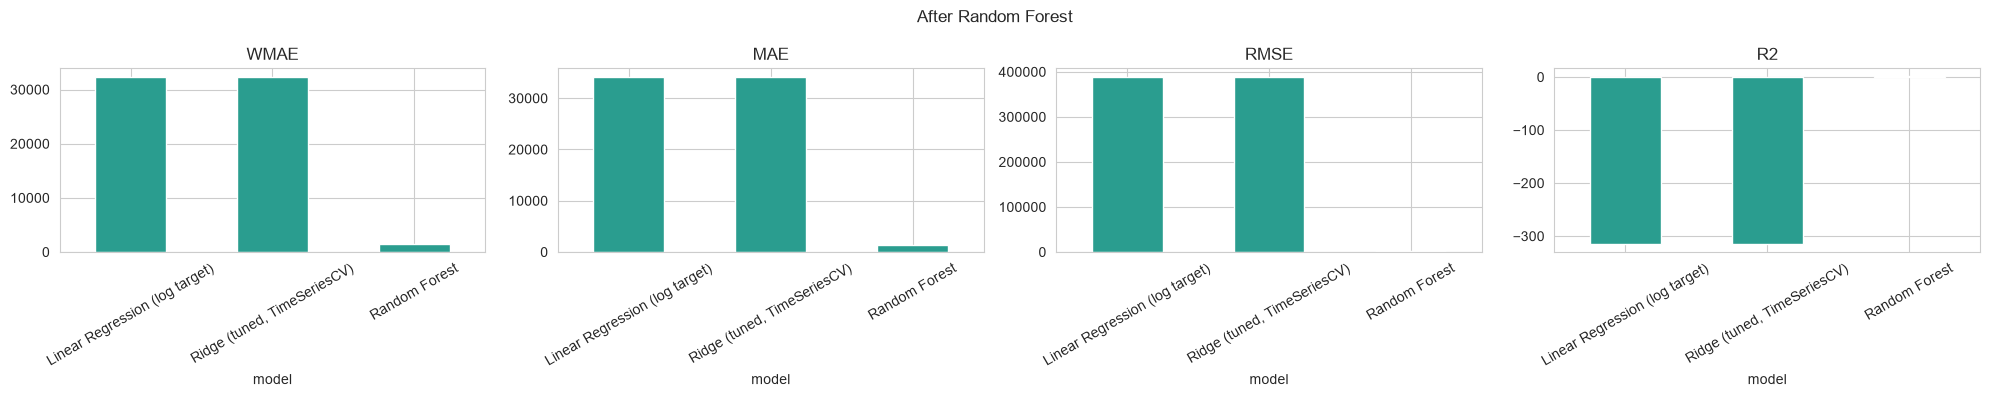

In [58]:
# Visualizing evaluation Metric Score chart
_ = score_chart(RESULTS, "After Random Forest")

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
rf_params = {"n_estimators": [150, 250, 400], "max_depth": [15, 20, 30, None], "min_samples_leaf": [1, 3, 5, 10],
             "max_features": [0.3, 0.5, 0.8]}
rf_search = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE), rf_params, n_iter=8,
                               cv=TimeSeriesSplit(n_splits=3), scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, verbose=1)
# tune on a smaller sample to keep runtime reasonable
tune_idx = train.sample(min(60_000, len(train)), random_state=RANDOM_STATE).sort_values("Date").index
rf_search.fit(X_train.loc[tune_idx], y_train.loc[tune_idx])
print("Best params:", rf_search.best_params_)
rf_best = RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE, **rf_search.best_params_).fit(
    X_train.loc[idx], y_train.loc[idx], sample_weight=w_train[train.index.get_indexer(idx)])
pred_rf_t = rf_best.predict(X_test)
evaluate("Random Forest (tuned)", y_test, pred_rf_t, w_test, RESULTS)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 250, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 15}
Random Forest (tuned)            WMAE=     1,502  MAE=     1,403  RMSE=     3,001  R2=0.9812


{'model': 'Random Forest (tuned)',
 'WMAE': np.float64(1502.1479776181422),
 'MAE': 1402.5616852993323,
 'RMSE': 3001.092457192198,
 'R2': 0.9812171920221731}

##### Which hyperparameter optimization technique have you used and why?

`RandomizedSearchCV` (8 candidates) with `TimeSeriesSplit(3)` is used on a 60K-row chronological tuning sample. Random Forest has several interacting parameters, so random search provides a practical balance between coverage and runtime.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The tuned Random Forest **does not improve** the hold-out result. Baseline RF gives **WMAE ≈ 1,485**, while tuned RF gives **WMAE ≈ 1,502** (about **1.2% worse**). This is a useful result rather than a failure: the original RF configuration generalises slightly better on the final 12-week period.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

* **WMAE (primary):** dollar error per Store-Department-week with holiday observations weighted 5×, aligning evaluation with the periods where stock-outs/over-stocks are most costly.
* **MAE:** typical absolute error during ordinary planning.
* **RMSE:** penalises large misses more heavily, highlighting risk on extreme/holiday weeks.
* **R²:** communicates the proportion of sales variance captured by the model.

### ML Model - 3 : Gradient Boosting (XGBoost / LightGBM)

In [60]:
# ML Model - 3 Implementation
if xgb is not None:
    gb = xgb.XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=8, subsample=0.8, colsample_bytree=0.8,
                          objective="reg:squarederror", tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)
    gb_name = "XGBoost"
elif lgb is not None:
    gb = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.05, num_leaves=63, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1)
    gb_name = "LightGBM"
else:
    from sklearn.ensemble import HistGradientBoostingRegressor
    gb = HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, max_depth=8, random_state=RANDOM_STATE)
    gb_name = "HistGradientBoosting (sklearn)"
# Fit the Algorithm
t0 = time.time(); gb.fit(X_train, y_train, sample_weight=w_train); print(f"{gb_name} fit time {time.time()-t0:.0f}s")
# Predict on the model
pred_gb = gb.predict(X_test)
evaluate(gb_name, y_test, pred_gb, w_test, RESULTS)

XGBoost fit time 28s
XGBoost                          WMAE=     1,343  MAE=     1,267  RMSE=     2,621  R2=0.9857


{'model': 'XGBoost',
 'WMAE': np.float64(1342.6695748734276),
 'MAE': 1267.0396542803946,
 'RMSE': 2621.4294155650514,
 'R2': 0.9856689469110651}

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

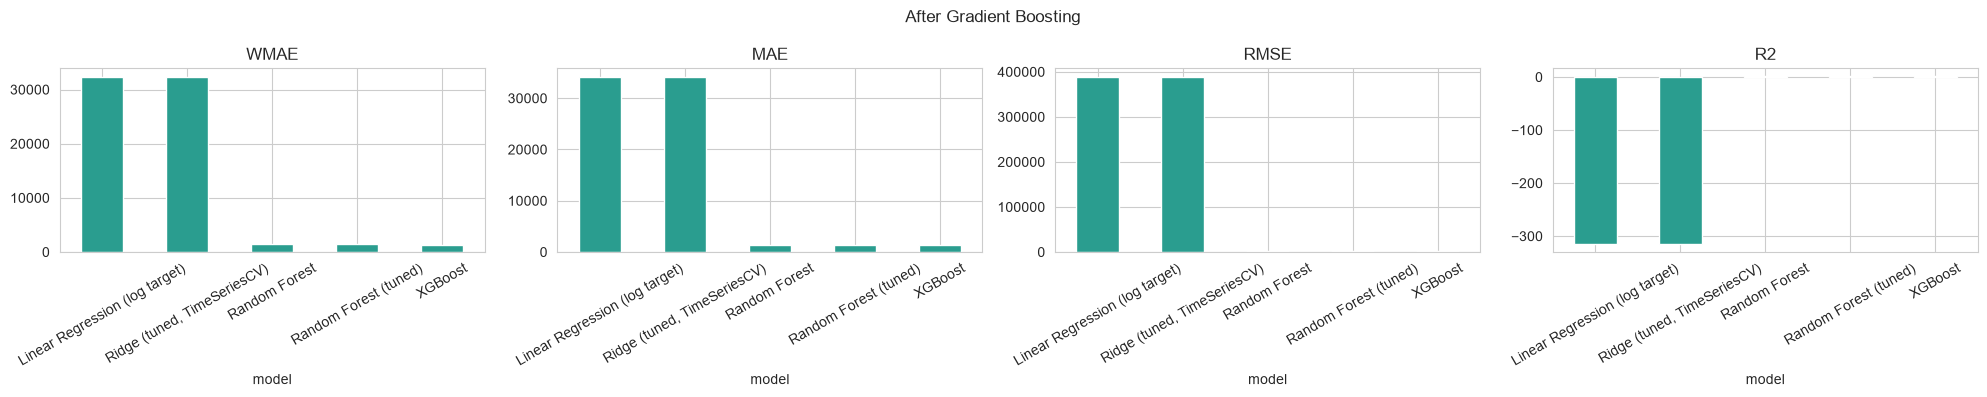

In [61]:
# Visualizing evaluation Metric Score chart
_ = score_chart(RESULTS, "After Gradient Boosting")

#### 2. Cross- Validation & Hyperparameter Tuning

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.8, 'n_estimators': 1200, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.02, 'colsample_bytree': 0.6}
XGBoost (tuned)                  WMAE=     1,309  MAE=     1,232  RMSE=     2,566  R2=0.9863


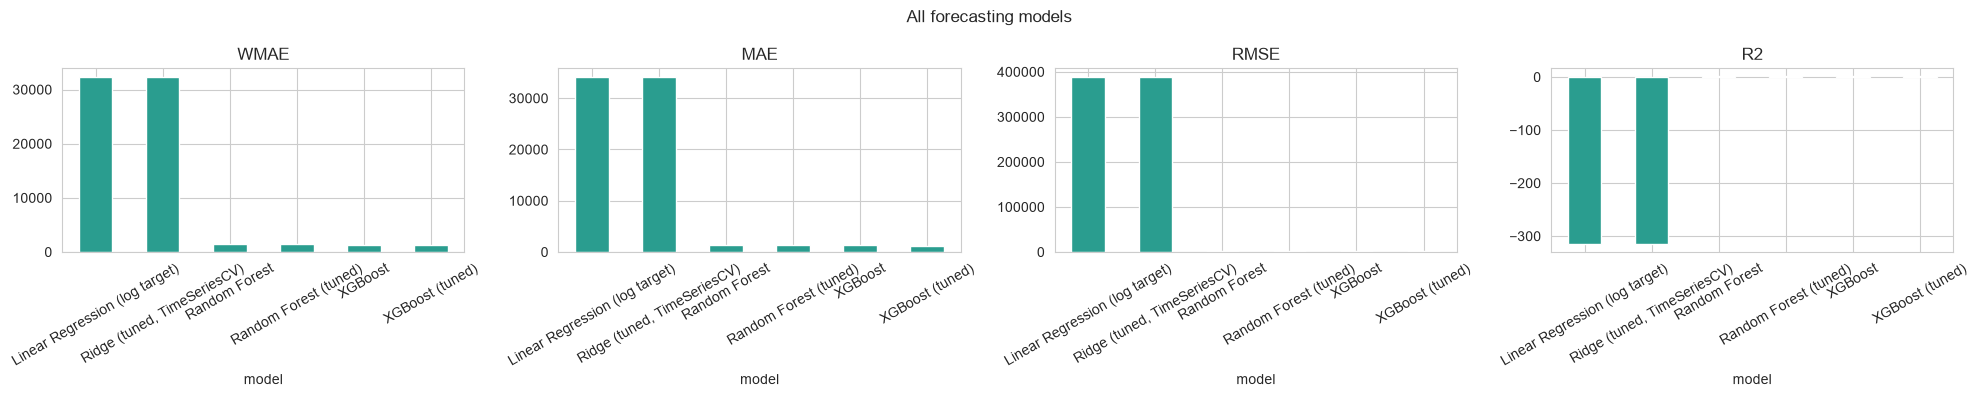

,WMAE,MAE,RMSE,R2
model,,,,
Linear Regression (log target),32342.365,34163.669,388724.852,-314.128
"Ridge (tuned, TimeSeriesCV)",32342.365,34163.668,388724.845,-314.128
Random Forest,1484.786,1386.061,2951.686,0.982
Random Forest (tuned),1502.148,1402.562,3001.092,0.981
XGBoost,1342.670,1267.040,2621.429,0.986
XGBoost (tuned),1309.426,1231.836,2565.665,0.986


In [62]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
if xgb is not None:
    gb_params = {"n_estimators": [400, 800, 1200], "learning_rate": [0.02, 0.05, 0.1], "max_depth": [6, 8, 10, 12],
                 "subsample": [0.7, 0.8, 1.0], "colsample_bytree": [0.6, 0.8, 1.0], "min_child_weight": [1, 5, 10]}
    base = xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)
elif lgb is not None:
    gb_params = {"n_estimators": [400, 800, 1200], "learning_rate": [0.02, 0.05, 0.1], "num_leaves": [31, 63, 127],
                 "subsample": [0.7, 0.8, 1.0], "colsample_bytree": [0.6, 0.8, 1.0], "min_child_samples": [10, 20, 50]}
    base = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
else:
    from sklearn.ensemble import HistGradientBoostingRegressor
    gb_params = {"max_iter": [400, 800], "learning_rate": [0.03, 0.05, 0.1], "max_depth": [6, 8, 12], "min_samples_leaf": [10, 20, 50]}
    base = HistGradientBoostingRegressor(random_state=RANDOM_STATE)

gb_search = RandomizedSearchCV(base, gb_params, n_iter=10, cv=TimeSeriesSplit(n_splits=3), scoring="neg_mean_absolute_error",
                               random_state=RANDOM_STATE, verbose=1, n_jobs=1)
gb_search.fit(X_train.loc[tune_idx], y_train.loc[tune_idx])
print("Best params:", gb_search.best_params_)
gb_best = base.set_params(**gb_search.best_params_).fit(X_train, y_train, sample_weight=w_train)
pred_gb_t = gb_best.predict(X_test)
evaluate(f"{gb_name} (tuned)", y_test, pred_gb_t, w_test, RESULTS)
final_scores = score_chart(RESULTS, "All forecasting models")
display(final_scores.round(3))

##### Which hyperparameter optimization technique have you used and why?

`RandomizedSearchCV` (10 candidates) with `TimeSeriesSplit(3)` is used across XGBoost parameters including learning rate, tree depth, estimators, row/column subsampling and child-weight regularisation. Random search is much more efficient than a full grid for this interacting parameter space.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Baseline XGBoost gives **WMAE ≈ 1,343**, while tuned XGBoost gives **WMAE ≈ 1,309**, an improvement of about **2.5%**. The tuned model also improves MAE from ≈1,267 to ≈1,232 and RMSE from ≈2,621 to ≈2,566, while R² increases to approximately **0.9863**. It is therefore the best model in the formal three-model comparison.

#### Forecast diagnostics: actual vs predicted, error by holiday / cluster / dept

Best model by WMAE: XGBoost (tuned)


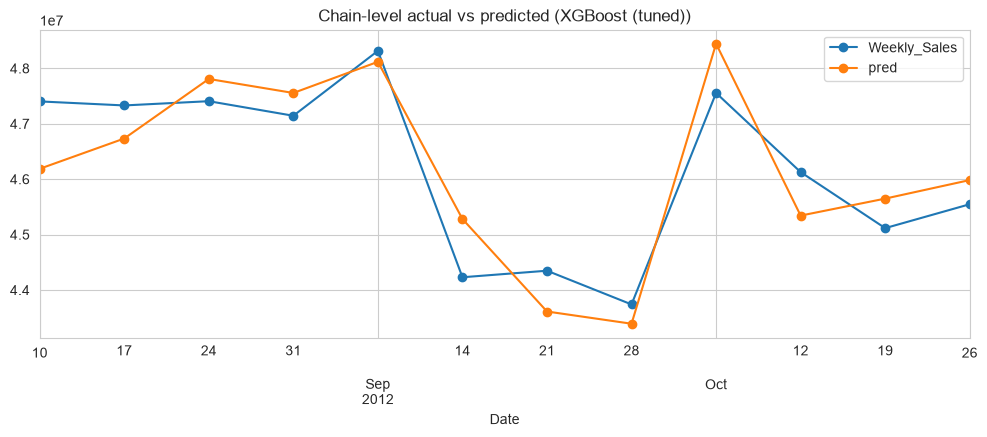

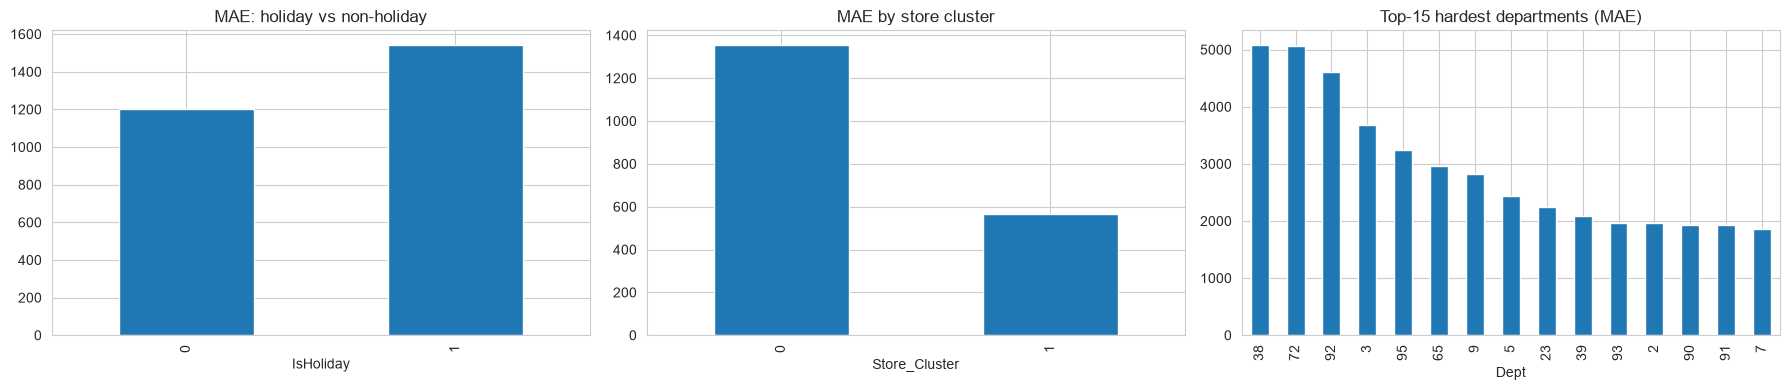

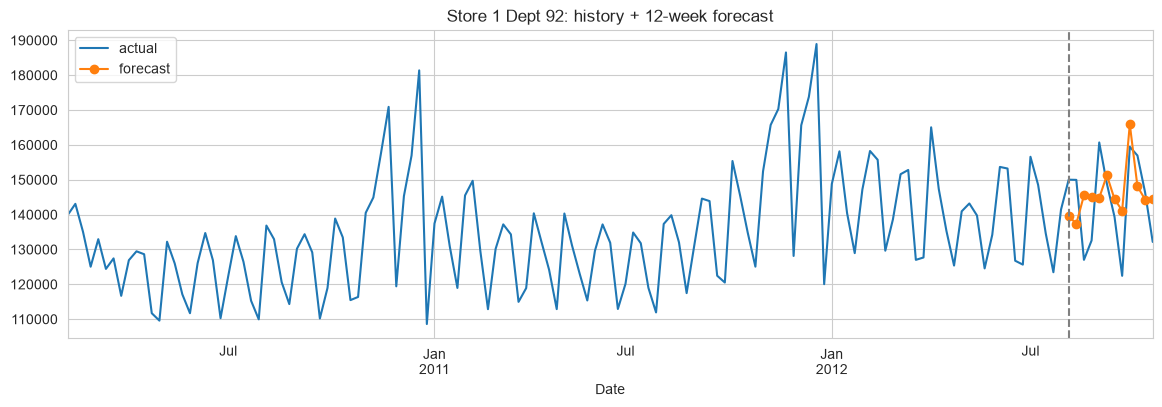

In [63]:
# Diagnostics on the best model (pick by WMAE)
best_name = min(RESULTS, key=lambda r: r["WMAE"])["model"]
best_pred = {"Linear Regression (log target)": pred_lin, "Ridge (tuned, TimeSeriesCV)": pred_ridge, "Random Forest": pred_rf,
             "Random Forest (tuned)": pred_rf_t, gb_name: pred_gb, f"{gb_name} (tuned)": pred_gb_t}.get(best_name, pred_gb_t)
print("Best model by WMAE:", best_name)
test_eval = test[["Store","Dept","Date","IsHoliday","Holiday_Name","Store_Cluster","Weekly_Sales"]].copy()
test_eval["pred"] = best_pred; test_eval["abs_err"] = (test_eval.pred - test_eval.Weekly_Sales).abs()

# chain-level actual vs predicted
agg = test_eval.groupby("Date")[["Weekly_Sales","pred"]].sum()
plt.figure(figsize=(12, 4)); agg.plot(ax=plt.gca(), marker="o"); plt.title(f"Chain-level actual vs predicted ({best_name})"); plt.show()

# error breakdowns
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
test_eval.groupby("IsHoliday").abs_err.mean().plot.bar(ax=ax[0], title="MAE: holiday vs non-holiday")
test_eval.groupby("Store_Cluster").abs_err.mean().plot.bar(ax=ax[1], title="MAE by store cluster")
test_eval.groupby("Dept").abs_err.mean().sort_values(ascending=False).head(15).plot.bar(ax=ax[2], title="Top-15 hardest departments (MAE)")
plt.tight_layout(); plt.show()

# example series
s, d = 1, 92
ex = df[(df.Store == s) & (df.Dept == d)].set_index("Date").Weekly_Sales
plt.figure(figsize=(14, 4)); ex.plot(label="actual")
test_eval[(test_eval.Store == s) & (test_eval.Dept == d)].set_index("Date").pred.plot(label="forecast", marker="o")
plt.axvline(pd.Timestamp(cutoff), color="grey", ls="--"); plt.legend(); plt.title(f"Store {s} Dept {d}: history + 12-week forecast"); plt.show()

#### Long-term forecasting: SARIMA on chain-level weekly sales

SARIMA order: (2, 0, 2) seasonal: (1, 0, 0, 52)


c:\Users\pkjos\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\pkjos\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


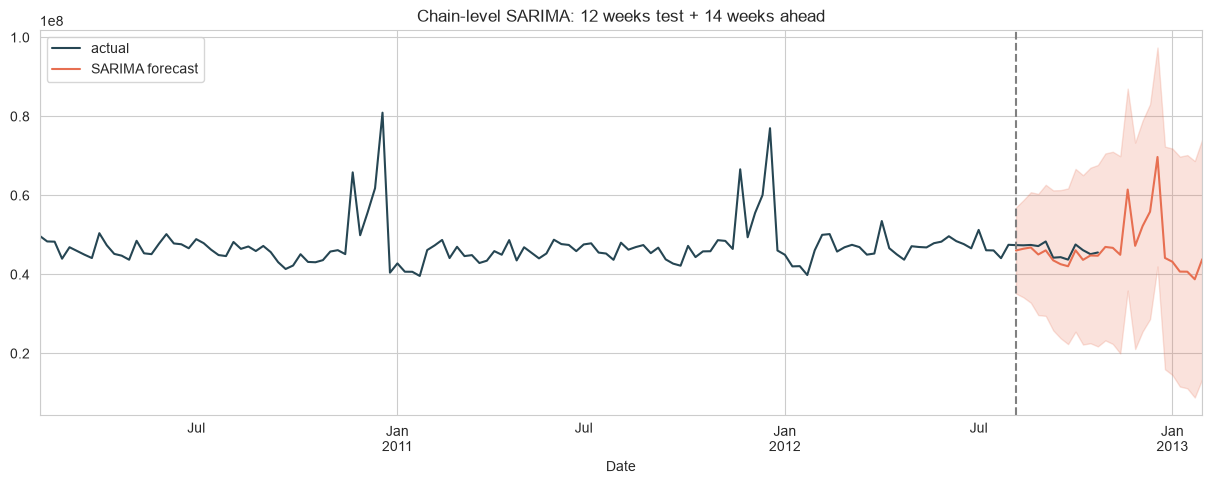

SARIMA test MAPE: 2.96%
ML best model chain-level MAPE: 1.37%


In [64]:
# Long-horizon (26-week) forecast of total chain sales with SARIMA (statistical time-series model)
from statsmodels.tsa.statespace.sarimax import SARIMAX
ts_train, ts_test = ts[ts.index < cutoff], ts[ts.index >= cutoff]
try:
    if pmdarima is not None:
        auto = pmdarima.auto_arima(ts_train, seasonal=True, m=52, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=3, max_q=3)
        order, sorder = auto.order, auto.seasonal_order
    else:
        order, sorder = (1, 1, 1), (1, 1, 0, 52)
    print("SARIMA order:", order, "seasonal:", sorder)
    sar = SARIMAX(ts_train, order=order, seasonal_order=sorder, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = sar.get_forecast(steps=len(ts_test) + 14)
    fc_mean, fc_ci = fc.predicted_mean, fc.conf_int()
    plt.figure(figsize=(15, 5)); ts.plot(label="actual", color="#264653"); fc_mean.plot(label="SARIMA forecast", color="#e76f51")
    plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color="#e76f51", alpha=.2); plt.axvline(pd.Timestamp(cutoff), color="grey", ls="--")
    plt.legend(); plt.title("Chain-level SARIMA: 12 weeks test + 14 weeks ahead"); plt.show()
    print("SARIMA test MAPE: {:.2%}".format(np.mean(np.abs(ts_test - fc_mean[:len(ts_test)]) / ts_test)))
    # compare with ML model aggregated to chain level
    print("ML best model chain-level MAPE: {:.2%}".format(np.mean(np.abs(agg.Weekly_Sales - agg.pred) / agg.Weekly_Sales)))
except Exception as e:
    print("SARIMA step skipped:", e)

##### Short-term vs long-term forecasting

* **Short-term (1–12 weeks):** tuned XGBoost is the preferred Store-Department forecaster because it models nonlinear interactions among rolling demand, store/department attributes, holidays, markdowns and contextual variables.
* **Longer-range aggregate planning:** SARIMA provides a seasonal chain-level planning view when detailed future lag features are not yet available.
* On the held-out period, **ML chain-level MAPE = 1.37%** and **SARIMA test MAPE = 2.96%**, so the machine-learning model is stronger for the current short-term horizon while SARIMA remains useful as an aggregate seasonal benchmark/planning envelope.

### 7E. Impact of External Factors on the forecast

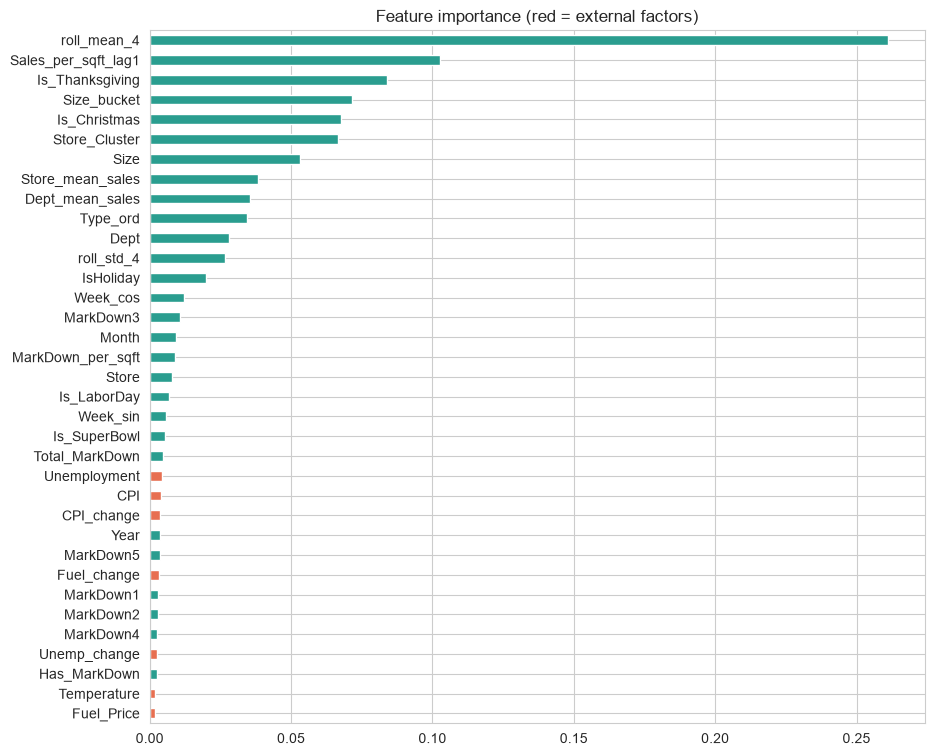

External-factor share of total importance: 2.2%


In [65]:
# E1. Feature importance of the tuned gradient-boosting model, external factors highlighted
try:
    imp_gb = pd.Series(gb_best.feature_importances_, index=FEATURES).sort_values(ascending=False)
except AttributeError:
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(gb_best, X_test.sample(20000, random_state=RANDOM_STATE), y_test.loc[X_test.sample(20000, random_state=RANDOM_STATE).index], n_repeats=3, random_state=RANDOM_STATE)
    imp_gb = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
ext_cols = ["CPI","Unemployment","Fuel_Price","Temperature","CPI_change","Fuel_change","Unemp_change"]
colors = ["#e76f51" if f in ext_cols else "#2a9d8f" for f in imp_gb.index]
plt.figure(figsize=(10, 9)); imp_gb.plot.barh(color=colors); plt.gca().invert_yaxis(); plt.title("Feature importance (red = external factors)"); plt.show()
print("External-factor share of total importance: {:.1%}".format(imp_gb[[c for c in ext_cols if c in imp_gb.index]].sum() / imp_gb.sum()))

In [66]:
# E2. Ablation: retrain the boosting model WITHOUT external factors and compare WMAE
feat_no_ext = [f for f in FEATURES if f not in ext_cols]
from sklearn.base import clone
gb_no_ext = clone(gb_best).fit(X_train[feat_no_ext], y_train, sample_weight=w_train)
evaluate(f"{gb_name} tuned - NO external factors", y_test, gb_no_ext.predict(X_test[feat_no_ext]), w_test)
evaluate(f"{gb_name} tuned - WITH external factors", y_test, pred_gb_t, w_test)

XGBoost tuned - NO external factors WMAE=     1,244  MAE=     1,177  RMSE=     2,466  R2=0.9873
XGBoost tuned - WITH external factors WMAE=     1,309  MAE=     1,232  RMSE=     2,566  R2=0.9863


{'model': 'XGBoost tuned - WITH external factors',
 'WMAE': np.float64(1309.4261305239056),
 'MAE': 1231.8355632261946,
 'RMSE': 2565.664837174213,
 'R2': 0.986272178853796}

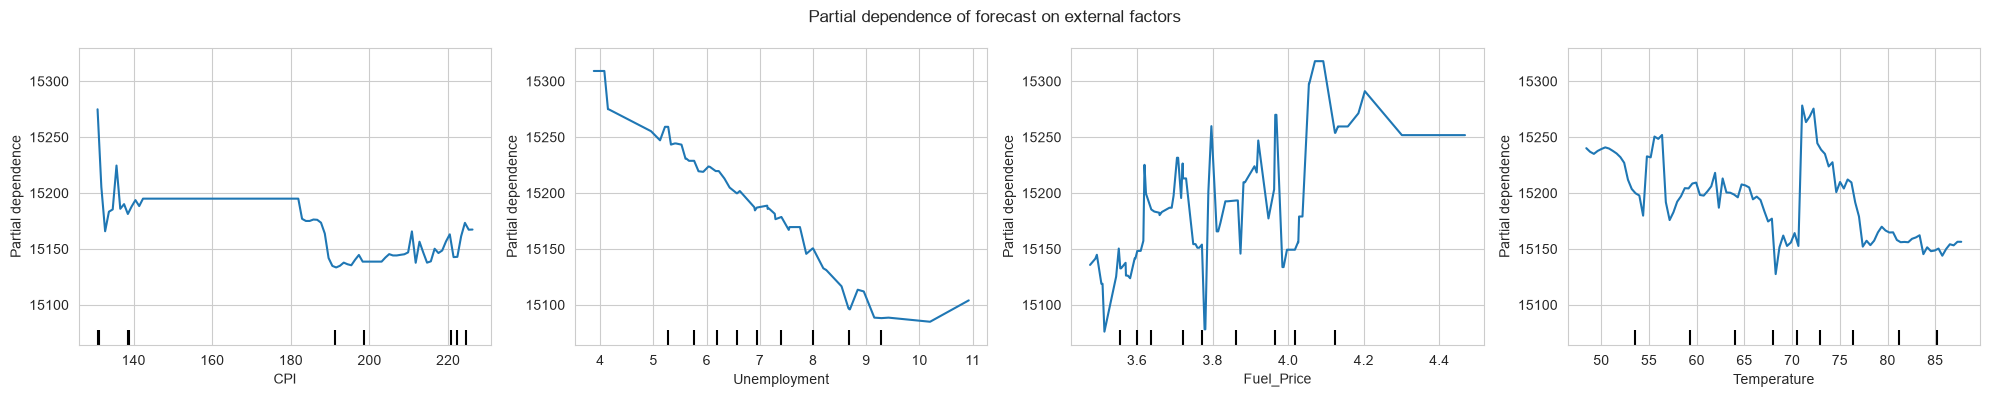

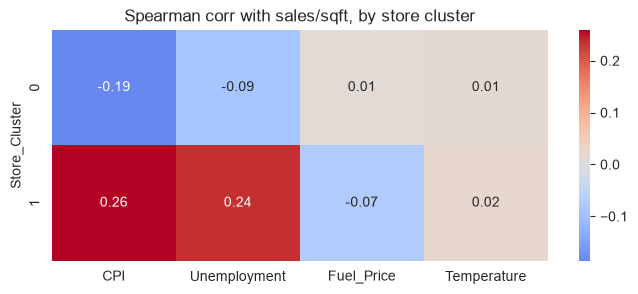

In [67]:
# E3. Partial dependence: how does predicted sales respond to each external factor, holding others at their mean?
from sklearn.inspection import PartialDependenceDisplay
pd_sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
PartialDependenceDisplay.from_estimator(gb_best, pd_sample, ["CPI","Unemployment","Fuel_Price","Temperature"], ax=ax, kind="average")
plt.suptitle("Partial dependence of forecast on external factors"); plt.tight_layout(); plt.show()

# E4. Store-cluster-specific sensitivity: correlation of external factor with sales-per-sqft inside each cluster
sw3 = df.groupby(["Store","Date"]).agg(sales=("Weekly_Sales","sum"), Size=("Size","first"), Store_Cluster=("Store_Cluster","first"),
                                       CPI=("CPI","first"), Unemployment=("Unemployment","first"), Fuel_Price=("Fuel_Price","first"), Temperature=("Temperature","first")).reset_index()
sw3["sales_per_sqft"] = sw3.sales / sw3.Size
sens = sw3.groupby("Store_Cluster")[["CPI","Unemployment","Fuel_Price","Temperature","sales_per_sqft"]].corr(method="spearman")["sales_per_sqft"].unstack().drop(columns="sales_per_sqft")
plt.figure(figsize=(8, 3)); sns.heatmap(sens, annot=True, fmt=".2f", cmap="coolwarm", center=0); plt.title("Spearman corr with sales/sqft, by store cluster"); plt.show()

##### Impact analysis — how external factors influence sales and the forecast

* The external variables (`CPI`, `Unemployment`, `Fuel_Price`, `Temperature` and their changes) account for only about **2.2% of total model feature importance** in the executed tuned XGBoost.
* The ablation test is important: the model **without external factors performs better**, with WMAE ≈ **1,244** compared with ≈ **1,309** when they are included (roughly a **5% reduction in WMAE**). Therefore, the current evidence does **not** support claiming that external variables improve forecast accuracy.
* Partial-dependence and cluster-level correlation plots remain useful for understanding directional sensitivity and store-segment context, but they should be treated as diagnostic associations rather than causal effects.
* CPI in particular varies substantially by region/store, so some apparent CPI signal can represent location differences rather than a pure time-varying economic effect.
* For production, the lean no-external specification should be retested across multiple rolling hold-outs before deciding whether the macro variables are retained.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**WMAE** is the primary forecasting metric because it is expressed in sales units and weights holiday weeks 5×, directly reflecting periods where planning errors have greater business impact. **MAE** measures typical error, **RMSE** highlights large misses, and **R²** communicates overall explanatory strength. Segmentation is evaluated with **silhouette, Davies-Bouldin and Calinski-Harabasz** scores, while association rules are interpreted using **support, confidence and lift**.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

For the formal three-model comparison and saved deployment bundle, **tuned XGBoost** is selected. It achieves the lowest WMAE among Linear/Ridge, Random Forest and XGBoost: **WMAE ≈ 1,309, MAE ≈ 1,232, RMSE ≈ 2,566 and R² ≈ 0.9863**. It captures nonlinear interactions between store, department, recent demand, holiday and promotion variables while remaining efficient at inference.

The external-factor ablation is reported separately: a no-external XGBoost variant reaches WMAE ≈ 1,244, so production model selection should re-test that leaner specification across several rolling validation windows.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

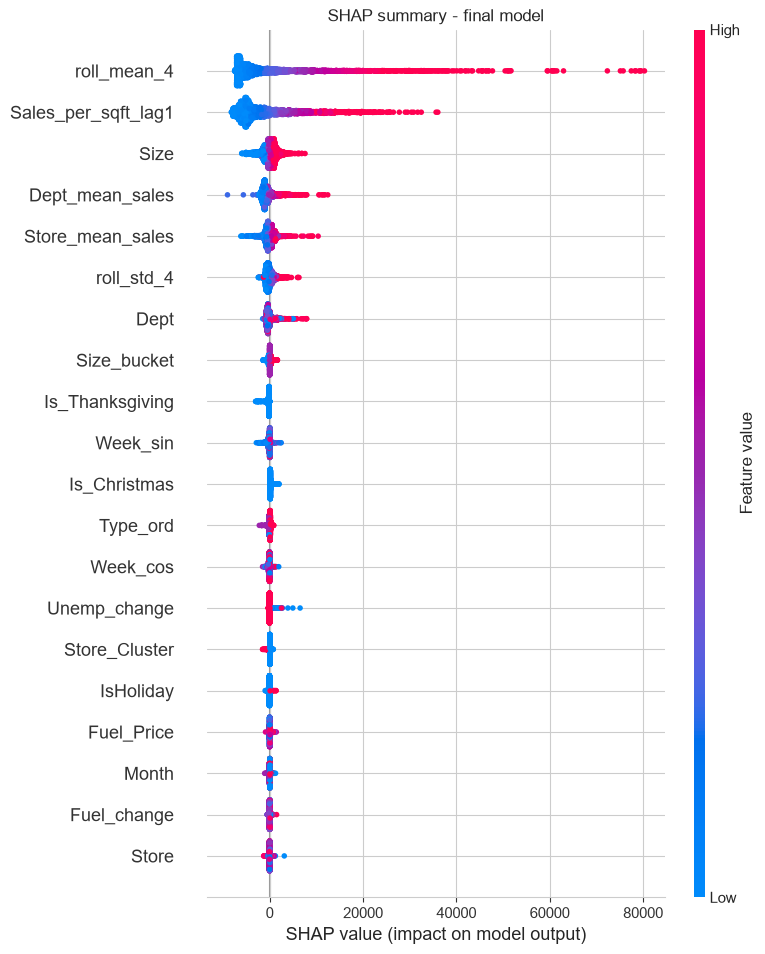

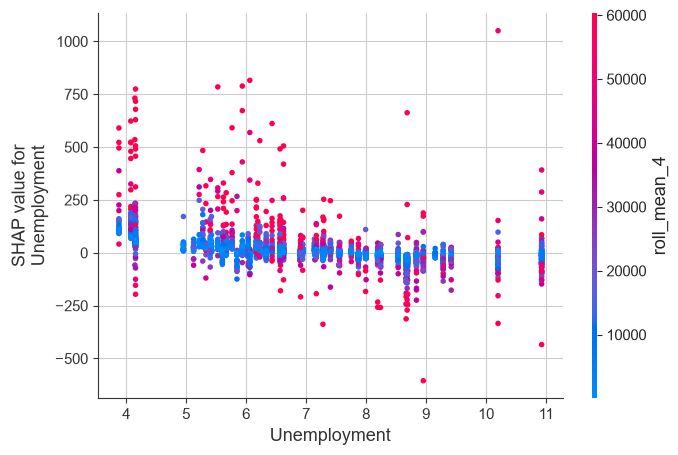

In [68]:
# SHAP explainability on the final model (falls back gracefully if shap unavailable)
shap = _try_import("shap")
if shap is not None:
    try:
        explainer = shap.TreeExplainer(gb_best)
        Xs = X_test.sample(min(3000, len(X_test)), random_state=RANDOM_STATE)
        sv = explainer.shap_values(Xs)
        shap.summary_plot(sv, Xs, max_display=20, show=False); plt.title("SHAP summary - final model"); plt.show()
        shap.dependence_plot("Unemployment", sv, Xs, show=False); plt.show()
    except Exception as e:
        print("SHAP skipped:", e)
else:
    print("shap not available - see feature-importance and partial-dependence plots in 7E.")

The final prediction model is an ensemble of **gradient-boosted decision trees (XGBoost)**. Trees are added sequentially so that each new tree focuses on correcting residual errors made by the preceding ensemble. This makes the model well suited to nonlinear interactions such as Store × Department × season × holiday effects.

Both built-in feature importance and SHAP were used for explainability. The strongest drivers in the executed model are **`roll_mean_4`** and **`Sales_per_sqft_lag1`**, followed by store/department scale and seasonal variables including **Size, `Dept_mean_sales`, `Store_mean_sales`, `Is_Thanksgiving`, `Is_Christmas`, `Size_bucket` and `Store_Cluster`**. SHAP confirms that recent rolling demand has the largest effect on individual predictions. External economic features are much smaller overall; together they account for only **2.2%** of feature importance.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [69]:
# Save the File
os.makedirs("models", exist_ok=True)
joblib.dump({"model": gb_best, "features": FEATURES, "scaler": scaler, "store_clusters": profile.cluster_km.to_dict(),
             "kmeans": kmeans, "isolation_forest": iso, "iso_features": iso_feats},
            "models/retail_forecast_bundle.joblib")
profile.to_csv("models/store_segments.csv")
df[df.anom_any == 1][["Store","Dept","Date","Weekly_Sales_raw","anom_reason","iso_score"]].to_csv("models/anomaly_report.csv", index=False)
print("Saved: models/retail_forecast_bundle.joblib, store_segments.csv, anomaly_report.csv")

Saved: models/retail_forecast_bundle.joblib, store_segments.csv, anomaly_report.csv


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [70]:
# Load the File and predict unseen data.
bundle = joblib.load("models/retail_forecast_bundle.joblib")
sample_rows = X_test.sample(5, random_state=RANDOM_STATE)
pred_check = bundle["model"].predict(sample_rows[bundle["features"]])
display(pd.DataFrame({"actual": y_test.loc[sample_rows.index].round(0), "predicted": pred_check.round(0)}))
assert np.allclose(pred_check, gb_best.predict(sample_rows[FEATURES])), "Reloaded model disagrees with in-memory model"
print("Sanity check passed.")

,actual,predicted
206190,10680.0,10341.0
96907,11277.0,11665.0
106128,24728.0,24422.0
177326,18526.0,21239.0
169612,15008.0,13626.0


Sanity check passed.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

## ***9. Real-World Application & Strategy Formulation***

### 9.1 Inventory management strategy

| Lever | Recommendation | Evidence |
|---|---|---|
| Segment-based safety stock | Use a wider buffer for Cluster 0, which has higher sales volume, promotion intensity and anomaly rate; run Cluster 1 leaner. | 7B segment profiles |
| Holiday pre-positioning | Increase replenishment readiness around Thanksgiving and Christmas instead of treating every holiday identically. | Charts 7/12; 7A anomaly concentration |
| Department prioritisation | Give tighter replenishment cadence to the high-volume and hardest-to-forecast departments identified by the forecasting diagnostics. | Chart 6; 7D error breakdown |
| Short vs long horizon | Use tuned XGBoost for weekly Store-Department planning and SARIMA as an aggregate seasonal planning benchmark. | 7D: ML MAPE 1.37%, SARIMA 2.96% |

### 9.2 Store-segment strategy

| Segment | Observed profile | Suggested operating approach |
|---|---|---|
| **Cluster 0 — Large / higher-volume / promotion-active** | 36 stores; avg weekly sales ≈17.1K, size ≈152.9K sq ft, markdown intensity ≈1.292, anomaly rate ≈5.1% | Larger holiday buffers, closer promotion monitoring, targeted cross-department bundles and faster anomaly review |
| **Cluster 1 — Small / lower-volume / higher sales-per-sq-ft** | 9 stores; avg weekly sales ≈8.7K, size ≈40.0K sq ft, sales/sq-ft ≈0.216, anomaly rate ≈2.5% | Lean replenishment, value-focused offers, avoid excessive markdown depth, monitor local economic sensitivity |

### 9.3 Cross-selling / merchandising

* Test adjacency or bundles for strongly co-moving department pairs such as **81–92**, **92–95** and **81–95**.
* Use high-lift Apriori rules as prioritisation signals, not proof of customer-level co-purchase.
* Treat negative correlations such as **14–38** as possible substitution/cannibalisation candidates requiring merchandising validation.

### 9.4 External-factor strategy

The executed ablation shows that macro variables do not improve forecast accuracy in the current specification: WMAE improves from ≈1,309 to ≈1,244 when they are removed. Therefore they should be retained primarily for **diagnostic/store-context analysis** unless repeated rolling validation demonstrates stable predictive benefit.

### 9.5 Real-world implementation challenges

1. **Data latency and revision:** CPI/unemployment may be published after the week being forecast.
2. **No transaction/customer IDs:** association analysis measures department co-movement rather than genuine basket co-purchase.
3. **Promotional causality:** anonymised markdown variables limit causal interpretation and cannibalisation measurement.
4. **Concept drift:** demand patterns can change, requiring rolling retraining and monitoring.
5. **Forecast hierarchy:** production deployment should reconcile department/store forecasts with regional and chain totals.

# **Conclusion**

This project demonstrates an end-to-end retail analytics workflow across **45 stores, 81 departments and 421,570 weekly sales observations**. It combines exploratory analysis, statistical testing, anomaly detection, store segmentation, inferred department associations, demand forecasting, model explainability and practical strategy formulation.

Three complementary anomaly methods identify unusual sales behaviour without simply deleting high-value retail events. Robust z-score flags 3.81% of rows, Isolation Forest flags 1.00%, and the consolidated classification identifies 19,869 anomalous observations (4.71%). Many anomalies are associated with holidays or markdown activity, reinforcing the need to distinguish genuine commercial events from data errors.

Store segmentation produces **two operational groups** with silhouette **0.437** and Davies-Bouldin **0.990**. Cluster 0 contains larger, higher-volume and more promotion-active stores, while Cluster 1 contains smaller stores with lower absolute sales but higher sales per square foot. Department co-movement and Apriori provide cross-merchandising signals, including a strong Dept 81–92 relationship (corr ≈0.820), while remaining explicitly limited by the absence of transaction-level basket data.

For forecasting, tuned **XGBoost** is the strongest model in the formal three-model comparison, achieving **WMAE ≈1,309, RMSE ≈2,566 and R² ≈0.9863** on the final 12-week hold-out. At chain level, ML MAPE is **1.37%**, compared with **2.96% for SARIMA**. External factors contribute only 2.2% of feature importance, and the ablation test shows that removing them improves WMAE to ≈1,244; therefore, their predictive value should be validated across additional rolling hold-outs before production use.

Overall, the strongest operational value comes from combining recent demand signals, holiday-aware forecasting, store segmentation and anomaly monitoring into differentiated inventory and merchandising decisions.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***